<a href="https://colab.research.google.com/github/squistanchala-ai/Taller_3_Matematicas_Discretas/blob/main/Taller_3_Discretas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1.) Cifrado César

In [8]:
# ==========================================================
# EJERCICIO 1: CIFRADO CÉSAR
# ==========================================================

def desplazar_caracter(caracter, desplazamiento):
    """
    Desplaza una letra dentro del alfabeto latino de 26 letras.

    Los espacios, números, signos de puntuación y cualquier otro
    carácter que no pertenezca al alfabeto A-Z se conservan.
    """

    if 'A' <= caracter <= 'Z':
        posicion_inicial = ord('A')
        posicion = ord(caracter) - posicion_inicial
        nueva_posicion = (posicion + desplazamiento) % 26
        return chr(posicion_inicial + nueva_posicion)

    if 'a' <= caracter <= 'z':
        posicion_inicial = ord('a')
        posicion = ord(caracter) - posicion_inicial
        nueva_posicion = (posicion + desplazamiento) % 26
        return chr(posicion_inicial + nueva_posicion)

    # Los caracteres que no son letras se mantienen sin cambios.
    return caracter


def cifrar_cesar(texto, k):
    """
    Cifra un texto usando un desplazamiento k.
    """
    return ''.join(
        desplazar_caracter(caracter, k)
        for caracter in texto
    )


def descifrar_cesar(texto_cifrado, k):
    """
    Descifra un texto aplicando el desplazamiento contrario.
    """
    return cifrar_cesar(texto_cifrado, -k)


def ataque_fuerza_bruta(texto_cifrado):
    """
    Genera los 26 posibles descifrados de un mensaje cuando
    no se conoce el desplazamiento k.
    """

    resultados = []

    for k in range(26):
        posible_mensaje = descifrar_cesar(texto_cifrado, k)
        resultados.append((k, posible_mensaje))

    return resultados


# ==========================================================
# MENÚ PRINCIPAL
# ==========================================================

def mostrar_menu():
    while True:
        print("\n" + "=" * 50)
        print("CIFRADO CÉSAR")
        print("=" * 50)
        print("1. Cifrar un mensaje")
        print("2. Descifrar un mensaje con k conocido")
        print("3. Romper un mensaje mediante fuerza bruta")
        print("4. Salir")

        opcion = input("\nSeleccione una opción: ").strip()

        if opcion == "1":
            texto = input("Ingrese el texto que desea cifrar: ")

            try:
                k = int(input("Ingrese el desplazamiento k: "))
                texto_cifrado = cifrar_cesar(texto, k)

                print("\nTexto original: ", texto)
                print("Texto cifrado:  ", texto_cifrado)

            except ValueError:
                print("Error: el desplazamiento debe ser un número entero.")

        elif opcion == "2":
            texto = input("Ingrese el texto que desea descifrar: ")

            try:
                k = int(input("Ingrese el desplazamiento k: "))
                texto_descifrado = descifrar_cesar(texto, k)

                print("\nTexto cifrado:   ", texto)
                print("Texto descifrado:", texto_descifrado)

            except ValueError:
                print("Error: el desplazamiento debe ser un número entero.")

        elif opcion == "3":
            texto = input("Ingrese el texto cifrado: ")

            print("\nPosibles mensajes:")
            print("-" * 50)

            for k, posible_mensaje in ataque_fuerza_bruta(texto):
                print(f"k = {k:2d} → {posible_mensaje}")

        elif opcion == "4":
            print("Programa finalizado.")
            break

        else:
            print("Opción no válida. Intente nuevamente.")


# Ejecutar el programa
mostrar_menu()


CIFRADO CÉSAR
1. Cifrar un mensaje
2. Descifrar un mensaje con k conocido
3. Romper un mensaje mediante fuerza bruta
4. Salir

Seleccione una opción: 1
Ingrese el texto que desea cifrar: hola UNAL
Ingrese el desplazamiento k: 3

Texto original:  hola UNAL
Texto cifrado:   krod XQDO

CIFRADO CÉSAR
1. Cifrar un mensaje
2. Descifrar un mensaje con k conocido
3. Romper un mensaje mediante fuerza bruta
4. Salir

Seleccione una opción: 3
Ingrese el texto cifrado: krod XQDO

Posibles mensajes:
--------------------------------------------------
k =  0 → krod XQDO
k =  1 → jqnc WPCN
k =  2 → ipmb VOBM
k =  3 → hola UNAL
k =  4 → gnkz TMZK
k =  5 → fmjy SLYJ
k =  6 → elix RKXI
k =  7 → dkhw QJWH
k =  8 → cjgv PIVG
k =  9 → bifu OHUF
k = 10 → ahet NGTE
k = 11 → zgds MFSD
k = 12 → yfcr LERC
k = 13 → xebq KDQB
k = 14 → wdap JCPA
k = 15 → vczo IBOZ
k = 16 → ubyn HANY
k = 17 → taxm GZMX
k = 18 → szwl FYLW
k = 19 → ryvk EXKV
k = 20 → qxuj DWJU
k = 21 → pwti CVIT
k = 22 → ovsh BUHS
k = 23 → nurg ATGR


In [13]:
# ==========================================================
# PRUEBAS DEL PROGRAMA
# ==========================================================

# Prueba 1: caso indicado en el taller
texto_1 = "HOLA UNAL"
k_1 = 3
cifrado_1 = cifrar_cesar(texto_1, k_1)
descifrado_1 = descifrar_cesar(cifrado_1, k_1)

print("PRUEBA 1")
print("Original:   ", texto_1)
print("Cifrado:    ", cifrado_1)
print("Descifrado: ", descifrado_1)

assert cifrado_1 == "KROD XQDO"
assert descifrado_1 == texto_1


# Prueba 2: minúsculas, números y puntuación
texto_2 = "Matematicas Discretas 1!"
k_2 = 5
cifrado_2 = cifrar_cesar(texto_2, k_2)
descifrado_2 = descifrar_cesar(cifrado_2, k_2)

print("\nPRUEBA 2")
print("Original:   ", texto_2)
print("Cifrado:    ", cifrado_2)
print("Descifrado: ", descifrado_2)

assert descifrado_2 == texto_2


# Prueba 3: desplazamiento mayor que 26
texto_3 = "XYZ abc"
k_3 = 29  # Equivale a desplazar 3 posiciones
cifrado_3 = cifrar_cesar(texto_3, k_3)
descifrado_3 = descifrar_cesar(cifrado_3, k_3)

print("\nPRUEBA 3")
print("Original:   ", texto_3)
print("Cifrado:    ", cifrado_3)
print("Descifrado: ", descifrado_3)

assert cifrado_3 == "ABC def"
assert descifrado_3 == texto_3




PRUEBA 1
Original:    HOLA UNAL
Cifrado:     KROD XQDO
Descifrado:  HOLA UNAL

PRUEBA 2
Original:    Matematicas Discretas 1!
Cifrado:     Rfyjrfynhfx Inxhwjyfx 1!
Descifrado:  Matematicas Discretas 1!

PRUEBA 3
Original:    XYZ abc
Cifrado:     ABC def
Descifrado:  XYZ abc


# 2.) RSA de juguete

In [15]:
# ==========================================================
# EJERCICIO 2: RSA DE JUGUETE
# ==========================================================

def es_primo(numero):
    """Determina si un número entero es primo."""

    if numero < 2:
        return False

    if numero == 2:
        return True

    if numero % 2 == 0:
        return False

    divisor = 3

    while divisor * divisor <= numero:
        if numero % divisor == 0:
            return False
        divisor += 2

    return True


def mcd(a, b):
    """Calcula el máximo común divisor."""

    while b != 0:
        a, b = b, a % b

    return abs(a)


def euclides_extendido(a, b):
    """
    Encuentra enteros x, y tales que:
        ax + by = MCD(a,b)
    """

    if b == 0:
        return a, 1, 0

    divisor, x1, y1 = euclides_extendido(b, a % b)

    x = y1
    y = x1 - (a // b) * y1

    return divisor, x, y


def inverso_modular(e, modulo):
    """Calcula el inverso modular de e."""

    divisor, x, _ = euclides_extendido(e, modulo)

    if divisor != 1:
        raise ValueError(
            f"e = {e} no tiene inverso módulo {modulo}, "
            f"porque MCD({e}, {modulo}) = {divisor}."
        )

    return x % modulo


def potencia_modular(base, exponente, modulo):
    """Calcula base^exponente módulo modulo."""

    resultado = 1
    base %= modulo

    while exponente > 0:
        if exponente % 2 == 1:
            resultado = (resultado * base) % modulo

        base = (base * base) % modulo
        exponente //= 2

    return resultado


def generar_llaves_rsa(p, q, e):
    """Genera las llaves pública y privada."""

    if not es_primo(p):
        raise ValueError(f"p = {p} no es primo.")

    if not es_primo(q):
        raise ValueError(f"q = {q} no es primo.")

    if p == q:
        raise ValueError("p y q deben ser diferentes.")

    n = p * q
    phi = (p - 1) * (q - 1)

    if not 1 < e < phi:
        raise ValueError(
            f"e debe cumplir 1 < e < φ(n) = {phi}."
        )

    divisor = mcd(e, phi)

    if divisor != 1:
        raise ValueError(
            f"e = {e} no es válido porque "
            f"MCD({e}, {phi}) = {divisor}, no 1."
        )

    d = inverso_modular(e, phi)

    return n, phi, d


def ejecutar_rsa(p, q, e, mensaje):
    """Genera las llaves, cifra y descifra el mensaje."""

    n, phi, d = generar_llaves_rsa(p, q, e)

    if not 0 <= mensaje < n:
        raise ValueError(
            f"El mensaje debe cumplir 0 <= M < n. "
            f"Como n = {n}, M = {mensaje} no es válido."
        )

    texto_cifrado = potencia_modular(mensaje, e, n)
    mensaje_recuperado = potencia_modular(texto_cifrado, d, n)

    return {
        "n": n,
        "phi": phi,
        "e": e,
        "d": d,
        "llave_publica": (e, n),
        "llave_privada": (d, n),
        "mensaje_original": mensaje,
        "texto_cifrado": texto_cifrado,
        "mensaje_recuperado": mensaje_recuperado
    }


def programa_principal():
    print("=" * 55)
    print("RSA DE JUGUETE")
    print("=" * 55)
    print("Este programa trabaja únicamente con mensajes numéricos.")
    print("No debe utilizarse como un sistema de seguridad real.\n")

    try:
        p = int(input("Ingrese el número primo p: "))
        q = int(input("Ingrese el número primo q: "))
        e = int(input("Ingrese el exponente público e: "))
        mensaje = int(input("Ingrese el mensaje numérico M: "))

        resultado = ejecutar_rsa(p, q, e, mensaje)

        print("\n" + "=" * 55)
        print("RESULTADOS")
        print("=" * 55)

        print(f"n = p·q = {resultado['n']}")
        print(f"φ(n) = (p - 1)(q - 1) = {resultado['phi']}")
        print(f"d = {resultado['d']}")
        print(f"Llave pública: {resultado['llave_publica']}")
        print(f"Llave privada: {resultado['llave_privada']}")
        print(f"Mensaje original: {resultado['mensaje_original']}")
        print(f"Mensaje cifrado: {resultado['texto_cifrado']}")
        print(f"Mensaje recuperado: {resultado['mensaje_recuperado']}")

        if resultado["mensaje_recuperado"] == mensaje:
            print("\nEl mensaje se recuperó correctamente.")

    except ValueError as error:
        print(f"\nError: {error}")


programa_principal()

RSA DE JUGUETE
Este programa trabaja únicamente con mensajes numéricos.
No debe utilizarse como un sistema de seguridad real.

Ingrese el número primo p: 61
Ingrese el número primo q: 53
Ingrese el exponente público e: 17
Ingrese el mensaje numérico M: 65

RESULTADOS
n = p·q = 3233
φ(n) = (p - 1)(q - 1) = 3120
d = 2753
Llave pública: (17, 3233)
Llave privada: (2753, 3233)
Mensaje original: 65
Mensaje cifrado: 2790
Mensaje recuperado: 65

El mensaje se recuperó correctamente.


In [43]:
# ==========================================================
# PRUEBAS DEL EJERCICIO 2: RSA
# ==========================================================

# PRUEBA 1: caso obligatorio
resultado_1 = ejecutar_rsa(
    p=61,
    q=53,
    e=17,
    mensaje=65
)

assert resultado_1["n"] == 3233
assert resultado_1["phi"] == 3120
assert resultado_1["d"] == 2753
assert resultado_1["texto_cifrado"] == 2790
assert resultado_1["mensaje_recuperado"] == 65

print("PRUEBA 1 CORRECTA")
print("Caso obligatorio verificado.")


# PRUEBA 2: otro caso válido
resultado_2 = ejecutar_rsa(
    p=11,
    q=13,
    e=7,
    mensaje=42
)

assert resultado_2["n"] == 143
assert resultado_2["phi"] == 120
assert resultado_2["d"] == 103
assert resultado_2["texto_cifrado"] == 81
assert resultado_2["mensaje_recuperado"] == 42

print("\nPRUEBA 2 CORRECTA")
print(f"Mensaje original = {resultado_2['mensaje_original']}")
print(f"Mensaje cifrado = {resultado_2['texto_cifrado']}")
print(f"Mensaje recuperado = {resultado_2['mensaje_recuperado']}")


# PRUEBA 3: exponente público no válido
try:
    ejecutar_rsa(
        p=11,
        q=13,
        e=12,
        mensaje=50
    )

except ValueError as error:
    print("\nPRUEBA 3 CORRECTA")
    print(f"Error detectado: {error}")

else:
    raise AssertionError(
        "El programa debía rechazar e = 12."
    )


# PRUEBA 4: número no primo
try:
    ejecutar_rsa(
        p=15,
        q=13,
        e=7,
        mensaje=50
    )

except ValueError as error:
    print("\nPRUEBA 4 CORRECTA")
    print(f"Error detectado: {error}")

else:
    raise AssertionError(
        "El programa debía rechazar p = 15."
    )



PRUEBA 1 CORRECTA
Caso obligatorio verificado.

PRUEBA 2 CORRECTA
Mensaje original = 42
Mensaje cifrado = 81
Mensaje recuperado = 42

PRUEBA 3 CORRECTA
Error detectado: e = 12 no es válido porque MCD(12, 120) = 12, no 1.

PRUEBA 4 CORRECTA
Error detectado: p = 15 no es primo.


# 3.) Computación multipartita segura (MPC).

In [18]:
# ==========================================================
# EJERCICIO 3: MPC BÁSICO
# SUMA Y PROMEDIO SIN REVELAR LAS NOTAS
# ==========================================================

import secrets


MODULO_PREDETERMINADO = 1_000_003


# ----------------------------------------------------------
# VALIDACIÓN DE LAS NOTAS
# ----------------------------------------------------------

def validar_notas(notas):
    """
    Verifica que la lista no esté vacía y que todas las notas
    sean números enteros entre 0 y 50.
    """

    if not notas:
        raise ValueError(
            "La lista de notas no puede estar vacía."
        )

    for nota in notas:

        if not isinstance(nota, int):
            raise TypeError(
                f"La nota {nota} no es un número entero."
            )

        if not 0 <= nota <= 50:
            raise ValueError(
                f"La nota {nota} no está entre 0 y 50."
            )


# ----------------------------------------------------------
# SELECCIÓN DEL MÓDULO
# ----------------------------------------------------------

def seleccionar_modulo(cantidad_notas):
    """
    Selecciona un módulo mayor que la máxima suma posible.

    Como cada nota puede valer máximo 50:

        suma máxima = 50 × cantidad de notas
    """

    suma_maxima = 50 * cantidad_notas

    return max(
        MODULO_PREDETERMINADO,
        suma_maxima + 1
    )


# ----------------------------------------------------------
# DIVISIÓN DE UNA NOTA EN TRES PARTES
# ----------------------------------------------------------

def dividir_secreto(valor, modulo):
    """
    Divide una nota x en tres partes aleatorias que cumplen:

        x ≡ s1 + s2 + s3 (mod M)

    Ninguna parte individual revela la nota original.
    """

    s1 = secrets.randbelow(modulo)
    s2 = secrets.randbelow(modulo)

    # La tercera parte garantiza que la suma modular
    # sea igual al valor original.
    s3 = (valor - s1 - s2) % modulo

    return s1, s2, s3


# ----------------------------------------------------------
# DISTRIBUCIÓN ENTRE LOS SERVIDORES
# ----------------------------------------------------------

def distribuir_notas(notas, modulo):
    """
    Cada nota se divide en tres partes.

    El servidor 1 recibe todas las partes s1.
    El servidor 2 recibe todas las partes s2.
    El servidor 3 recibe todas las partes s3.
    """

    servidor_1 = []
    servidor_2 = []
    servidor_3 = []

    for nota in notas:

        s1, s2, s3 = dividir_secreto(
            nota,
            modulo
        )

        servidor_1.append(s1)
        servidor_2.append(s2)
        servidor_3.append(s3)

    return servidor_1, servidor_2, servidor_3


# ----------------------------------------------------------
# SUMAS PARCIALES
# ----------------------------------------------------------

def calcular_suma_parcial(partes_servidor, modulo):
    """
    Cada servidor calcula solamente la suma de sus partes.
    """

    return sum(partes_servidor) % modulo


# ----------------------------------------------------------
# RECONSTRUCCIÓN DE LA SUMA
# ----------------------------------------------------------

def reconstruir_suma(sumas_parciales, modulo):
    """
    Combina las tres sumas parciales para recuperar
    la suma total.
    """

    return sum(sumas_parciales) % modulo


# ----------------------------------------------------------
# PROTOCOLO COMPLETO
# ----------------------------------------------------------

def calcular_promedio_privado(notas):
    """
    Ejecuta el protocolo MPC completo y reconstruye únicamente
    la suma total y el promedio.
    """

    validar_notas(notas)

    modulo = seleccionar_modulo(
        len(notas)
    )

    servidor_1, servidor_2, servidor_3 = distribuir_notas(
        notas,
        modulo
    )

    suma_servidor_1 = calcular_suma_parcial(
        servidor_1,
        modulo
    )

    suma_servidor_2 = calcular_suma_parcial(
        servidor_2,
        modulo
    )

    suma_servidor_3 = calcular_suma_parcial(
        servidor_3,
        modulo
    )

    sumas_parciales = [
        suma_servidor_1,
        suma_servidor_2,
        suma_servidor_3
    ]

    suma_reconstruida = reconstruir_suma(
        sumas_parciales,
        modulo
    )

    promedio = suma_reconstruida / len(notas)

    return {
        "cantidad_notas": len(notas),
        "modulo": modulo,
        "sumas_parciales": sumas_parciales,
        "suma": suma_reconstruida,
        "promedio": promedio
    }


# ----------------------------------------------------------
# PROGRAMA INTERACTIVO
# ----------------------------------------------------------

def programa_mpc():

    print("=" * 65)
    print("MPC: CÁLCULO PRIVADO DE SUMA Y PROMEDIO")
    print("=" * 65)

    print(
        "Ingrese notas enteras entre 0 y 50, "
        "separadas por comas."
    )

    print("Ejemplo: 40,35,50,25\n")

    try:
        entrada = input("Ingrese las notas: ")

        notas = [
            int(valor.strip())
            for valor in entrada.split(",")
        ]

        resultado = calcular_promedio_privado(
            notas
        )

        print("\n" + "=" * 65)
        print("RESULTADOS")
        print("=" * 65)

        print(
            f"Cantidad de notas: "
            f"{resultado['cantidad_notas']}"
        )

        print(
            f"Módulo utilizado: "
            f"{resultado['modulo']}"
        )

        print("\nSumas parciales entregadas:")

        for numero, suma_parcial in enumerate(
            resultado["sumas_parciales"],
            start=1
        ):
            print(
                f"Servidor {numero}: "
                f"{suma_parcial}"
            )

        print(
            f"\nSuma reconstruida: "
            f"{resultado['suma']}"
        )

        print(
            f"Promedio: "
            f"{resultado['promedio']:.2f}"
        )

        print(
            "\nLas notas individuales no fueron reveladas "
            "por los servidores."
        )

        return resultado

    except (ValueError, TypeError) as error:
        print(f"\nError: {error}")
        return None


resultado_mpc = programa_mpc()

MPC: CÁLCULO PRIVADO DE SUMA Y PROMEDIO
Ingrese notas enteras entre 0 y 50, separadas por comas.
Ejemplo: 40,35,50,25

Ingrese las notas: 40,35,50,25

RESULTADOS
Cantidad de notas: 4
Módulo utilizado: 1000003

Sumas parciales entregadas:
Servidor 1: 98283
Servidor 2: 540312
Servidor 3: 361558

Suma reconstruida: 150
Promedio: 37.50

Las notas individuales no fueron reveladas por los servidores.


In [39]:
# ==========================================================
# PRUEBAS DEL EJERCICIO 3: MPC
# ==========================================================

# ----------------------------------------------------------
# PRUEBA 1: CASO DEL ENUNCIADO
# ----------------------------------------------------------

resultado_1 = calcular_promedio_privado([40, 35, 50, 25])

assert resultado_1["suma"] == 150
assert resultado_1["promedio"] == 37.5

assert (
    sum(resultado_1["sumas_parciales"])
    % resultado_1["modulo"]
    == resultado_1["suma"]
)

print("PRUEBA 1 CORRECTA")
print(f"Suma reconstruida = {resultado_1['suma']}")
print(f"Promedio = {resultado_1['promedio']}")


# ----------------------------------------------------------
# PRUEBA 2: NOTAS MÍNIMA Y MÁXIMA
# ----------------------------------------------------------

resultado_2 = calcular_promedio_privado([0, 50, 20])

assert resultado_2["suma"] == 70
assert abs(resultado_2["promedio"] - 70 / 3) < 1e-12

print("\nPRUEBA 2 CORRECTA")
print(f"Suma reconstruida = {resultado_2['suma']}")
print(f"Promedio = {resultado_2['promedio']:.4f}")


# ----------------------------------------------------------
# PRUEBA 3: UNA SOLA NOTA
# ----------------------------------------------------------

resultado_3 = calcular_promedio_privado([45])

assert resultado_3["suma"] == 45
assert resultado_3["promedio"] == 45

print("\nPRUEBA 3 CORRECTA")
print(f"Suma reconstruida = {resultado_3['suma']}")
print(f"Promedio = {resultado_3['promedio']}")


# ----------------------------------------------------------
# PRUEBA 4: NOTA FUERA DEL RANGO
# ----------------------------------------------------------

try:
    calcular_promedio_privado([30, 55, 40])

except ValueError as error:
    print("\nPRUEBA 4 CORRECTA")
    print(f"Error detectado: {error}")

else:
    raise AssertionError(
        "El programa debía rechazar la nota 55."
    )


# ----------------------------------------------------------
# PRUEBA 5: LISTA VACÍA
# ----------------------------------------------------------

try:
    calcular_promedio_privado([])

except ValueError as error:
    print("\nPRUEBA 5 CORRECTA")
    print(f"Error detectado: {error}")

else:
    raise AssertionError(
        "El programa debía rechazar la lista vacía."
    )


PRUEBA 1 CORRECTA
Suma reconstruida = 150
Promedio = 37.5

PRUEBA 2 CORRECTA
Suma reconstruida = 70
Promedio = 23.3333

PRUEBA 3 CORRECTA
Suma reconstruida = 45
Promedio = 45.0

PRUEBA 4 CORRECTA
Error detectado: La nota 55 no está entre 0 y 50.

PRUEBA 5 CORRECTA
Error detectado: La lista de notas no puede estar vacía.


# 4.) GRAFO PONDERADO

In [19]:
# ==========================================================
# EJERCICIO 4: RUTA MÁS CORTA MEDIANTE DIJKSTRA
# ==========================================================

import heapq
from math import inf


# ----------------------------------------------------------
# CREACIÓN DEL GRAFO
# ----------------------------------------------------------

def crear_grafo():
    """
    Crea un grafo vacío representado mediante una lista
    de adyacencia.

    Cada vértice tendrá una lista de pares:
        (vecino, peso)
    """

    return {}


def agregar_vertice(grafo, vertice):
    """
    Agrega un vértice al grafo si todavía no existe.
    """

    if vertice not in grafo:
        grafo[vertice] = []


def agregar_arista(grafo, origen, destino, peso):
    """
    Agrega una arista no dirigida entre origen y destino.

    Como la red permite viajar en ambos sentidos, la conexión
    se guarda tanto desde origen hacia destino como desde
    destino hacia origen.
    """

    if peso < 0:
        raise ValueError(
            "Dijkstra no permite aristas con pesos negativos."
        )

    agregar_vertice(grafo, origen)
    agregar_vertice(grafo, destino)

    grafo[origen].append((destino, peso))
    grafo[destino].append((origen, peso))


def crear_red_ciudad():
    """
    Construye un grafo de prueba con:

        8 vértices
        14 aristas

    Los pesos representan tiempos aproximados de viaje
    en minutos.
    """

    grafo = crear_grafo()

    conexiones = [
        ("Portal", "Calle 80", 7),
        ("Portal", "Terminal", 10),
        ("Calle 80", "Estadio", 4),
        ("Calle 80", "Calle 26", 6),
        ("Terminal", "Calle 26", 3),
        ("Terminal", "Universidad", 8),
        ("Calle 26", "Estadio", 5),
        ("Calle 26", "Universidad", 4),
        ("Estadio", "Universidad", 3),
        ("Estadio", "Museo", 7),
        ("Universidad", "Museo", 4),
        ("Universidad", "Centro", 6),
        ("Museo", "Centro", 2),
        ("Calle 26", "Museo", 9)
    ]

    for origen, destino, peso in conexiones:
        agregar_arista(
            grafo,
            origen,
            destino,
            peso
        )

    return grafo


# ----------------------------------------------------------
# VALIDACIÓN DEL GRAFO
# ----------------------------------------------------------

def validar_grafo(grafo):
    """
    Verifica que el grafo no esté vacío y que todos sus
    pesos sean no negativos.
    """

    if not grafo:
        raise ValueError("El grafo no puede estar vacío.")

    for origen, conexiones in grafo.items():
        for destino, peso in conexiones:
            if peso < 0:
                raise ValueError(
                    f"La conexión {origen} - {destino} "
                    f"tiene peso negativo: {peso}."
                )


# ----------------------------------------------------------
# ALGORITMO DE DIJKSTRA
# ----------------------------------------------------------

def dijkstra(grafo, origen, destino):
    """
    Encuentra la ruta más corta entre dos vértices mediante
    el algoritmo de Dijkstra.

    Retorna:
        distancia mínima
        ruta encontrada
    """

    validar_grafo(grafo)

    if origen not in grafo:
        raise ValueError(
            f"El vértice de origen '{origen}' no existe."
        )

    if destino not in grafo:
        raise ValueError(
            f"El vértice de destino '{destino}' no existe."
        )

    # Inicialmente, todas las distancias son infinitas.
    distancias = {
        vertice: inf
        for vertice in grafo
    }

    # Guarda desde qué vértice se llegó a cada lugar.
    anteriores = {
        vertice: None
        for vertice in grafo
    }

    distancias[origen] = 0

    # La cola de prioridad guarda pares:
    # (distancia acumulada, vértice)
    cola_prioridad = [(0, origen)]

    visitados = set()

    while cola_prioridad:

        distancia_actual, vertice_actual = heapq.heappop(
            cola_prioridad
        )

        # Si ya fue procesado, se ignora.
        if vertice_actual in visitados:
            continue

        visitados.add(vertice_actual)

        # Cuando se extrae el destino, su distancia ya es mínima.
        if vertice_actual == destino:
            break

        for vecino, peso in grafo[vertice_actual]:

            if peso < 0:
                raise ValueError(
                    "Dijkstra no funciona con pesos negativos."
                )

            nueva_distancia = distancia_actual + peso

            # Relajación de la arista:
            # se actualiza si encontramos un camino más corto.
            if nueva_distancia < distancias[vecino]:
                distancias[vecino] = nueva_distancia
                anteriores[vecino] = vertice_actual

                heapq.heappush(
                    cola_prioridad,
                    (nueva_distancia, vecino)
                )

    # Si la distancia sigue siendo infinita, no existe ruta.
    if distancias[destino] == inf:
        return inf, []

    # Reconstrucción de la ruta desde el destino.
    ruta = []
    vertice_actual = destino

    while vertice_actual is not None:
        ruta.append(vertice_actual)
        vertice_actual = anteriores[vertice_actual]

    ruta.reverse()

    return distancias[destino], ruta


# ----------------------------------------------------------
# FUNCIONES PARA MOSTRAR EL GRAFO
# ----------------------------------------------------------

def obtener_aristas(grafo):
    """
    Obtiene las aristas del grafo sin repetirlas.
    """

    aristas = []
    registradas = set()

    for origen, conexiones in grafo.items():
        for destino, peso in conexiones:

            identificador = frozenset([origen, destino])

            if identificador not in registradas:
                aristas.append((origen, destino, peso))
                registradas.add(identificador)

    return aristas


def mostrar_grafo(grafo):
    """
    Imprime los vértices y conexiones del grafo.
    """

    print("\nLUGARES DISPONIBLES:")

    for numero, vertice in enumerate(grafo, start=1):
        print(f"{numero}. {vertice}")

    print("\nCONEXIONES:")

    for origen, destino, peso in obtener_aristas(grafo):
        print(
            f"{origen:12} -- {destino:12} : "
            f"{peso} minutos"
        )


def buscar_nombre_vertice(grafo, nombre):
    """
    Permite encontrar un vértice sin diferenciar entre
    mayúsculas y minúsculas.
    """

    nombre_buscado = nombre.strip().lower()

    for vertice in grafo:
        if vertice.lower() == nombre_buscado:
            return vertice

    raise ValueError(
        f"El lugar '{nombre}' no existe en el grafo."
    )


# ----------------------------------------------------------
# PROGRAMA PRINCIPAL
# ----------------------------------------------------------

def programa_principal():
    grafo = crear_red_ciudad()

    print("=" * 60)
    print("RUTA MÁS CORTA MEDIANTE DIJKSTRA")
    print("=" * 60)
    print(
        "Los pesos del grafo representan tiempos de viaje "
        "en minutos."
    )

    mostrar_grafo(grafo)

    try:
        origen_ingresado = input(
            "\nIngrese el lugar de origen: "
        )

        destino_ingresado = input(
            "Ingrese el lugar de destino: "
        )

        origen = buscar_nombre_vertice(
            grafo,
            origen_ingresado
        )

        destino = buscar_nombre_vertice(
            grafo,
            destino_ingresado
        )

        distancia, ruta = dijkstra(
            grafo,
            origen,
            destino
        )

        print("\n" + "=" * 60)
        print("RESULTADO")
        print("=" * 60)

        if distancia == inf:
            print(
                f"No existe una ruta entre "
                f"{origen} y {destino}."
            )

        else:
            print(f"Origen: {origen}")
            print(f"Destino: {destino}")
            print(f"Distancia total: {distancia} minutos")
            print(f"Ruta: {' → '.join(ruta)}")

    except ValueError as error:
        print(f"\nError: {error}")


programa_principal()

RUTA MÁS CORTA MEDIANTE DIJKSTRA
Los pesos del grafo representan tiempos de viaje en minutos.

LUGARES DISPONIBLES:
1. Portal
2. Calle 80
3. Terminal
4. Estadio
5. Calle 26
6. Universidad
7. Museo
8. Centro

CONEXIONES:
Portal       -- Calle 80     : 7 minutos
Portal       -- Terminal     : 10 minutos
Calle 80     -- Estadio      : 4 minutos
Calle 80     -- Calle 26     : 6 minutos
Terminal     -- Calle 26     : 3 minutos
Terminal     -- Universidad  : 8 minutos
Estadio      -- Calle 26     : 5 minutos
Estadio      -- Universidad  : 3 minutos
Estadio      -- Museo        : 7 minutos
Calle 26     -- Universidad  : 4 minutos
Calle 26     -- Museo        : 9 minutos
Universidad  -- Museo        : 4 minutos
Universidad  -- Centro       : 6 minutos
Museo        -- Centro       : 2 minutos

Ingrese el lugar de origen: Portal
Ingrese el lugar de destino: Museo

RESULTADO
Origen: Portal
Destino: Museo
Distancia total: 18 minutos
Ruta: Portal → Calle 80 → Estadio → Museo


In [20]:
# ==========================================================
# PRUEBAS DEL EJERCICIO 4
# ==========================================================

grafo_prueba = crear_red_ciudad()


# ----------------------------------------------------------
# PRUEBA 1: PORTAL A CENTRO
# ----------------------------------------------------------

distancia_1, ruta_1 = dijkstra(
    grafo_prueba,
    "Portal",
    "Centro"
)

print("PRUEBA 1")
print(f"Distancia: {distancia_1}")
print(f"Ruta: {' → '.join(ruta_1)}")

assert distancia_1 == 20
assert ruta_1[0] == "Portal"
assert ruta_1[-1] == "Centro"


# ----------------------------------------------------------
# PRUEBA 2: PORTAL A UNIVERSIDAD
# ----------------------------------------------------------

distancia_2, ruta_2 = dijkstra(
    grafo_prueba,
    "Portal",
    "Universidad"
)

print("\nPRUEBA 2")
print(f"Distancia: {distancia_2}")
print(f"Ruta: {' → '.join(ruta_2)}")

assert distancia_2 == 14
assert ruta_2 == [
    "Portal",
    "Calle 80",
    "Estadio",
    "Universidad"
]


# ----------------------------------------------------------
# PRUEBA 3: TERMINAL A MUSEO
# ----------------------------------------------------------

distancia_3, ruta_3 = dijkstra(
    grafo_prueba,
    "Terminal",
    "Museo"
)

print("\nPRUEBA 3")
print(f"Distancia: {distancia_3}")
print(f"Ruta: {' → '.join(ruta_3)}")

assert distancia_3 == 11
assert ruta_3 == [
    "Terminal",
    "Calle 26",
    "Universidad",
    "Museo"
]


# ----------------------------------------------------------
# PRUEBA 4: ORIGEN Y DESTINO IGUALES
# ----------------------------------------------------------

distancia_4, ruta_4 = dijkstra(
    grafo_prueba,
    "Museo",
    "Museo"
)

print("\nPRUEBA 4")
print(f"Distancia: {distancia_4}")
print(f"Ruta: {' → '.join(ruta_4)}")

assert distancia_4 == 0
assert ruta_4 == ["Museo"]


# ----------------------------------------------------------
# PRUEBA 5: VÉRTICE INEXISTENTE
# ----------------------------------------------------------

print("\nPRUEBA 5")

try:
    dijkstra(
        grafo_prueba,
        "Portal",
        "Aeropuerto"
    )

    raise AssertionError(
        "El programa debía rechazar el vértice inexistente."
    )

except ValueError as error:
    print(f"Error detectado correctamente: {error}")




PRUEBA 1
Distancia: 20
Ruta: Portal → Calle 80 → Estadio → Universidad → Centro

PRUEBA 2
Distancia: 14
Ruta: Portal → Calle 80 → Estadio → Universidad

PRUEBA 3
Distancia: 11
Ruta: Terminal → Calle 26 → Universidad → Museo

PRUEBA 4
Distancia: 0
Ruta: Museo

PRUEBA 5
Error detectado correctamente: El vértice de destino 'Aeropuerto' no existe.


# 5.) IMPACTO DEL CIERRE DE UNA ESTACIÓN

In [21]:
# ==========================================================
# EJERCICIO 5: IMPACTO DEL CIERRE DE UNA ESTACIÓN
# ==========================================================

from copy import deepcopy
from math import inf
import pandas as pd


# ----------------------------------------------------------
# ELIMINACIÓN DE UN VÉRTICE
# ----------------------------------------------------------

def eliminar_vertice(grafo, vertice):
    """
    Crea una copia del grafo y elimina completamente un vértice,
    junto con todas las aristas que llegan a él.
    """

    if vertice not in grafo:
        raise ValueError(
            f"El vértice '{vertice}' no existe en el grafo."
        )

    grafo_modificado = deepcopy(grafo)

    # Eliminar el vértice.
    del grafo_modificado[vertice]

    # Eliminar las conexiones hacia ese vértice.
    for origen in grafo_modificado:
        grafo_modificado[origen] = [
            (destino, peso)
            for destino, peso in grafo_modificado[origen]
            if destino != vertice
        ]

    return grafo_modificado


# ----------------------------------------------------------
# ELIMINACIÓN DE UNA ARISTA
# ----------------------------------------------------------

def eliminar_arista(grafo, vertice_1, vertice_2):
    """
    Crea una copia del grafo y elimina una conexión en
    ambos sentidos.
    """

    if vertice_1 not in grafo:
        raise ValueError(
            f"El vértice '{vertice_1}' no existe."
        )

    if vertice_2 not in grafo:
        raise ValueError(
            f"El vértice '{vertice_2}' no existe."
        )

    grafo_modificado = deepcopy(grafo)

    cantidad_antes = len(grafo_modificado[vertice_1])

    grafo_modificado[vertice_1] = [
        (vecino, peso)
        for vecino, peso in grafo_modificado[vertice_1]
        if vecino != vertice_2
    ]

    grafo_modificado[vertice_2] = [
        (vecino, peso)
        for vecino, peso in grafo_modificado[vertice_2]
        if vecino != vertice_1
    ]

    if len(grafo_modificado[vertice_1]) == cantidad_antes:
        raise ValueError(
            f"No existe una arista entre "
            f"'{vertice_1}' y '{vertice_2}'."
        )

    return grafo_modificado


# ----------------------------------------------------------
# CÁLCULO SEGURO DE UNA RUTA
# ----------------------------------------------------------

def calcular_ruta_segura(grafo, origen, destino):
    """
    Calcula una ruta teniendo en cuenta que alguno de los
    vértices pudo haber sido eliminado.

    Si no existe el origen, el destino o un camino entre ellos,
    retorna distancia infinita y una ruta vacía.
    """

    if origen not in grafo or destino not in grafo:
        return inf, []

    return dijkstra(grafo, origen, destino)


# ----------------------------------------------------------
# COMPARACIÓN ANTES Y DESPUÉS
# ----------------------------------------------------------

def analizar_impacto(grafo_original, grafo_modificado, pares):
    """
    Compara las rutas más cortas antes y después del cierre.

    Retorna:
        - una tabla con los resultados;
        - los detalles de las rutas encontradas.
    """

    resultados = []
    detalles = []

    for origen, destino in pares:

        distancia_antes, ruta_antes = calcular_ruta_segura(
            grafo_original,
            origen,
            destino
        )

        distancia_despues, ruta_despues = calcular_ruta_segura(
            grafo_modificado,
            origen,
            destino
        )

        if distancia_despues == inf:
            diferencia = None
            estado = "Desconectado"

        else:
            diferencia = distancia_despues - distancia_antes

            if diferencia > 0:
                estado = "Aumentó"

            elif diferencia == 0:
                estado = "Sin cambio"

            else:
                estado = "Disminuyó"

        resultados.append({
            "Origen": origen,
            "Destino": destino,
            "Distancia antes": distancia_antes,
            "Distancia después": (
                "∞" if distancia_despues == inf
                else distancia_despues
            ),
            "Diferencia": (
                "—" if diferencia is None
                else diferencia
            ),
            "Estado": estado
        })

        detalles.append({
            "origen": origen,
            "destino": destino,
            "ruta_antes": ruta_antes,
            "ruta_despues": ruta_despues,
            "distancia_antes": distancia_antes,
            "distancia_despues": distancia_despues,
            "estado": estado
        })

    tabla = pd.DataFrame(resultados)

    return tabla, detalles


# ----------------------------------------------------------
# MOSTRAR DETALLES DE LAS RUTAS
# ----------------------------------------------------------

def mostrar_detalles_rutas(detalles):
    """
    Muestra las rutas encontradas antes y después del cierre.
    """

    print("\n" + "=" * 70)
    print("DETALLE DE LAS RUTAS")
    print("=" * 70)

    for resultado in detalles:

        print(
            f"\n{resultado['origen']} → "
            f"{resultado['destino']}"
        )

        print(
            "Antes:   "
            + " → ".join(resultado["ruta_antes"])
            + f" ({resultado['distancia_antes']} minutos)"
        )

        if resultado["distancia_despues"] == inf:
            print("Después: no existe una ruta.")

        else:
            print(
                "Después: "
                + " → ".join(resultado["ruta_despues"])
                + f" ({resultado['distancia_despues']} minutos)"
            )

        print(f"Estado: {resultado['estado']}")


# ==========================================================
# EJECUCIÓN DEL EJERCICIO
# ==========================================================

grafo_original = crear_red_ciudad()

estacion_cerrada = "Universidad"

grafo_despues_cierre = eliminar_vertice(
    grafo_original,
    estacion_cerrada
)

# Se prueban cinco pares origen-destino.
pares_evaluados = [
    ("Portal", "Centro"),
    ("Terminal", "Centro"),
    ("Calle 26", "Centro"),
    ("Terminal", "Museo"),
    ("Universidad", "Centro")
]

tabla_resultados, detalles_resultados = analizar_impacto(
    grafo_original,
    grafo_despues_cierre,
    pares_evaluados
)

print("=" * 70)
print("IMPACTO DEL CIERRE DE UNA ESTACIÓN")
print("=" * 70)
print(f"Estación cerrada: {estacion_cerrada}\n")

display(tabla_resultados)

mostrar_detalles_rutas(detalles_resultados)

IMPACTO DEL CIERRE DE UNA ESTACIÓN
Estación cerrada: Universidad



,Origen,Destino,Distancia antes,Distancia después,Diferencia,Estado
0,Portal,Centro,20,20,0,Sin cambio
1,Terminal,Centro,13,14,1,Aumentó
2,Calle 26,Centro,10,11,1,Aumentó
3,Terminal,Museo,11,12,1,Aumentó
4,Universidad,Centro,6,∞,—,Desconectado



DETALLE DE LAS RUTAS

Portal → Centro
Antes:   Portal → Calle 80 → Estadio → Universidad → Centro (20 minutos)
Después: Portal → Calle 80 → Estadio → Museo → Centro (20 minutos)
Estado: Sin cambio

Terminal → Centro
Antes:   Terminal → Calle 26 → Universidad → Centro (13 minutos)
Después: Terminal → Calle 26 → Museo → Centro (14 minutos)
Estado: Aumentó

Calle 26 → Centro
Antes:   Calle 26 → Universidad → Centro (10 minutos)
Después: Calle 26 → Museo → Centro (11 minutos)
Estado: Aumentó

Terminal → Museo
Antes:   Terminal → Calle 26 → Universidad → Museo (11 minutos)
Después: Terminal → Calle 26 → Museo (12 minutos)
Estado: Aumentó

Universidad → Centro
Antes:   Universidad → Centro (6 minutos)
Después: no existe una ruta.
Estado: Desconectado


In [22]:
# ==========================================================
# PRUEBAS DEL EJERCICIO 5
# ==========================================================

# ----------------------------------------------------------
# PRUEBA 1: EL VÉRTICE FUE ELIMINADO
# ----------------------------------------------------------

assert "Universidad" in grafo_original
assert "Universidad" not in grafo_despues_cierre

print("PRUEBA 1: la estación fue eliminada correctamente.")


# ----------------------------------------------------------
# PRUEBA 2: NO QUEDAN CONEXIONES HACIA LA ESTACIÓN
# ----------------------------------------------------------

for origen, conexiones in grafo_despues_cierre.items():
    vecinos = [
        destino
        for destino, peso in conexiones
    ]

    assert "Universidad" not in vecinos

print("PRUEBA 2: se eliminaron todas sus conexiones.")


# ----------------------------------------------------------
# PRUEBA 3: UNA RUTA AUMENTÓ
# ----------------------------------------------------------

distancia_antes, _ = dijkstra(
    grafo_original,
    "Terminal",
    "Centro"
)

distancia_despues, _ = dijkstra(
    grafo_despues_cierre,
    "Terminal",
    "Centro"
)

assert distancia_antes == 13
assert distancia_despues == 14

print(
    "PRUEBA 3: Terminal → Centro aumentó "
    "de 13 a 14 minutos."
)


# ----------------------------------------------------------
# PRUEBA 4: UNA RUTA NO CAMBIÓ
# ----------------------------------------------------------

distancia_antes, _ = dijkstra(
    grafo_original,
    "Portal",
    "Centro"
)

distancia_despues, _ = dijkstra(
    grafo_despues_cierre,
    "Portal",
    "Centro"
)

assert distancia_antes == 20
assert distancia_despues == 20

print(
    "PRUEBA 4: Portal → Centro continúa "
    "con una distancia de 20 minutos."
)


# ----------------------------------------------------------
# PRUEBA 5: UN PAR QUEDÓ DESCONECTADO
# ----------------------------------------------------------

distancia, ruta = calcular_ruta_segura(
    grafo_despues_cierre,
    "Universidad",
    "Centro"
)

assert distancia == inf
assert ruta == []

print(
    "PRUEBA 5: Universidad → Centro quedó desconectado."
)


# ----------------------------------------------------------
# PRUEBA 6: EL GRAFO ORIGINAL NO FUE MODIFICADO
# ----------------------------------------------------------

assert "Universidad" in grafo_original

print("PRUEBA 6: el grafo original se conservó.")


PRUEBA 1: la estación fue eliminada correctamente.
PRUEBA 2: se eliminaron todas sus conexiones.
PRUEBA 3: Terminal → Centro aumentó de 13 a 14 minutos.
PRUEBA 4: Portal → Centro continúa con una distancia de 20 minutos.
PRUEBA 5: Universidad → Centro quedó desconectado.
PRUEBA 6: el grafo original se conservó.


# 6.) Coloreado de Grafos

In [23]:
# ==========================================================
# EJERCICIO 6: COLOREO VORAZ DE GRAFOS
# ORGANIZACIÓN DE EXÁMENES SIN CONFLICTOS
# ==========================================================


# ----------------------------------------------------------
# CREACIÓN DEL GRAFO
# ----------------------------------------------------------

def crear_grafo_conflictos(cursos, conflictos):
    """
    Construye un grafo no dirigido.

    cursos:
        Lista con los nombres de las materias.

    conflictos:
        Lista de pares (curso_1, curso_2). Cada par indica
        que ambos cursos tienen estudiantes en común.
    """

    grafo = {
        curso: set()
        for curso in cursos
    }

    for curso_1, curso_2 in conflictos:

        if curso_1 not in grafo:
            raise ValueError(
                f"El curso '{curso_1}' no está registrado."
            )

        if curso_2 not in grafo:
            raise ValueError(
                f"El curso '{curso_2}' no está registrado."
            )

        if curso_1 == curso_2:
            raise ValueError(
                f"Un curso no puede tener conflicto consigo mismo: "
                f"'{curso_1}'."
            )

        # Como el grafo es no dirigido, la conexión se agrega
        # en ambos sentidos.
        grafo[curso_1].add(curso_2)
        grafo[curso_2].add(curso_1)

    return grafo


# ----------------------------------------------------------
# ALGORITMO VORAZ DE COLOREO
# ----------------------------------------------------------

def coloreo_voraz(grafo):
    """
    Colorea los vértices mediante un algoritmo voraz.

    Los vértices se procesan de mayor a menor grado.
    Para cada vértice se selecciona el color positivo más
    pequeño que no haya sido usado por sus vecinos.
    """

    if not grafo:
        raise ValueError("El grafo no puede estar vacío.")

    # Se procesan primero los vértices con más conflictos.
    orden_vertices = sorted(
        grafo,
        key=lambda vertice: (
            -len(grafo[vertice]),
            vertice
        )
    )

    colores = {}

    for vertice in orden_vertices:

        # Colores que ya están siendo usados por los vecinos
        # que fueron procesados anteriormente.
        colores_vecinos = {
            colores[vecino]
            for vecino in grafo[vertice]
            if vecino in colores
        }

        # Se busca el primer color disponible.
        color_elegido = 1

        while color_elegido in colores_vecinos:
            color_elegido += 1

        colores[vertice] = color_elegido

    return colores, orden_vertices


# ----------------------------------------------------------
# VERIFICACIÓN DEL COLOREO
# ----------------------------------------------------------

def verificar_coloreo(grafo, colores):
    """
    Verifica que:

    1. Todos los vértices tengan color.
    2. Ningún par de vértices adyacentes tenga el mismo color.

    Retorna:
        es_valido
        lista de conflictos encontrados
    """

    conflictos_encontrados = []

    # Comprobar que todos los vértices tengan un color.
    for vertice in grafo:
        if vertice not in colores:
            conflictos_encontrados.append(
                f"El vértice '{vertice}' no tiene color."
            )

    # Comprobar los colores de los vértices adyacentes.
    aristas_revisadas = set()

    for vertice, vecinos in grafo.items():
        for vecino in vecinos:

            arista = frozenset([vertice, vecino])

            if arista in aristas_revisadas:
                continue

            aristas_revisadas.add(arista)

            if (
                vertice in colores
                and vecino in colores
                and colores[vertice] == colores[vecino]
            ):
                conflictos_encontrados.append(
                    f"'{vertice}' y '{vecino}' tienen "
                    f"el mismo color {colores[vertice]}."
                )

    es_valido = len(conflictos_encontrados) == 0

    return es_valido, conflictos_encontrados


# ----------------------------------------------------------
# AGRUPACIÓN POR FRANJAS
# ----------------------------------------------------------

def agrupar_por_color(colores):
    """
    Agrupa los cursos que pueden presentar el examen
    en la misma franja horaria.
    """

    grupos = {}

    for curso, color in colores.items():

        if color not in grupos:
            grupos[color] = []

        grupos[color].append(curso)

    for color in grupos:
        grupos[color].sort()

    return grupos


def contar_aristas(grafo):
    """
    Cuenta las aristas de un grafo no dirigido.
    """

    suma_grados = sum(
        len(vecinos)
        for vecinos in grafo.values()
    )

    # Cada arista aparece dos veces en la lista de adyacencia.
    return suma_grados // 2


def mostrar_resultados(grafo, colores, orden_vertices):
    """
    Muestra el orden de procesamiento, los colores asignados
    y la verificación del resultado.
    """

    grupos = agrupar_por_color(colores)
    cantidad_colores = len(grupos)

    print("=" * 70)
    print("COLOREO DE GRAFOS: PROGRAMACIÓN DE EXÁMENES")
    print("=" * 70)

    print(f"Número de cursos: {len(grafo)}")
    print(f"Número de conflictos: {contar_aristas(grafo)}")

    print("\nOrden de procesamiento:")

    for posicion, curso in enumerate(
        orden_vertices,
        start=1
    ):
        print(
            f"{posicion:2}. {curso:15} "
            f"Grado: {len(grafo[curso])}"
        )

    print("\nAsignación individual:")

    for curso in sorted(colores):
        print(
            f"{curso:15} → Franja {colores[curso]}"
        )

    print(
        f"\nCantidad de franjas utilizadas: "
        f"{cantidad_colores}"
    )

    print("\nCursos asignados a cada franja:")

    for color in sorted(grupos):
        cursos = ", ".join(grupos[color])
        print(f"Franja {color}: {cursos}")

    es_valido, conflictos = verificar_coloreo(
        grafo,
        colores
    )

    print("\nVerificación:")

    if es_valido:
        print(
            "El coloreo es válido: ninguna pareja de cursos "
            "en conflicto comparte la misma franja."
        )

    else:
        print("El coloreo no es válido.")

        for conflicto in conflictos:
            print(f"- {conflicto}")


# ==========================================================
# GRAFO DE CONFLICTOS DE PRUEBA
# ==========================================================

cursos = [
    "Cálculo",
    "Álgebra",
    "Física",
    "Programación",
    "Discretas",
    "Estadística",
    "Mecánica",
    "Termodinámica",
    "Circuitos",
    "Dibujo"
]

conflictos = [
    ("Cálculo", "Álgebra"),
    ("Cálculo", "Física"),
    ("Cálculo", "Programación"),
    ("Cálculo", "Estadística"),
    ("Cálculo", "Mecánica"),
    ("Cálculo", "Termodinámica"),

    ("Álgebra", "Física"),
    ("Álgebra", "Programación"),
    ("Álgebra", "Discretas"),
    ("Álgebra", "Estadística"),

    ("Física", "Mecánica"),
    ("Física", "Termodinámica"),
    ("Física", "Circuitos"),

    ("Programación", "Discretas"),
    ("Programación", "Circuitos"),

    ("Discretas", "Estadística"),
    ("Discretas", "Circuitos"),

    ("Estadística", "Termodinámica"),

    ("Mecánica", "Termodinámica"),
    ("Mecánica", "Dibujo"),

    ("Termodinámica", "Dibujo"),

    ("Circuitos", "Dibujo")
]


# Construcción y coloreo del grafo.
grafo_examenes = crear_grafo_conflictos(
    cursos,
    conflictos
)

colores_asignados, orden_procesamiento = coloreo_voraz(
    grafo_examenes
)

mostrar_resultados(
    grafo_examenes,
    colores_asignados,
    orden_procesamiento
)

COLOREO DE GRAFOS: PROGRAMACIÓN DE EXÁMENES
Número de cursos: 10
Número de conflictos: 22

Orden de procesamiento:
 1. Cálculo         Grado: 6
 2. Física          Grado: 5
 3. Termodinámica   Grado: 5
 4. Álgebra         Grado: 5
 5. Circuitos       Grado: 4
 6. Discretas       Grado: 4
 7. Estadística     Grado: 4
 8. Mecánica        Grado: 4
 9. Programación    Grado: 4
10. Dibujo          Grado: 3

Asignación individual:
Circuitos       → Franja 1
Cálculo         → Franja 1
Dibujo          → Franja 2
Discretas       → Franja 2
Estadística     → Franja 4
Física          → Franja 2
Mecánica        → Franja 4
Programación    → Franja 4
Termodinámica   → Franja 3
Álgebra         → Franja 3

Cantidad de franjas utilizadas: 4

Cursos asignados a cada franja:
Franja 1: Circuitos, Cálculo
Franja 2: Dibujo, Discretas, Física
Franja 3: Termodinámica, Álgebra
Franja 4: Estadística, Mecánica, Programación

Verificación:
El coloreo es válido: ninguna pareja de cursos en conflicto comparte la mi

In [24]:
# ==========================================================
# PRUEBAS DEL EJERCICIO 6
# ==========================================================

# ----------------------------------------------------------
# PRUEBA 1: GRAFO DE LOS 10 CURSOS
# ----------------------------------------------------------

es_valido, conflictos_detectados = verificar_coloreo(
    grafo_examenes,
    colores_asignados
)

assert len(grafo_examenes) == 10
assert es_valido
assert conflictos_detectados == []
assert len(colores_asignados) == 10

print("PRUEBA 1")
print("El grafo de 10 cursos fue coloreado correctamente.")
print(
    f"Colores utilizados: "
    f"{len(set(colores_asignados.values()))}"
)


# ----------------------------------------------------------
# PRUEBA 2: GRAFO COMPLETO CON 5 VÉRTICES
# ----------------------------------------------------------
#
# En un grafo completo, todos los vértices son adyacentes
# entre sí, por lo que cada uno necesita un color diferente.

vertices_completo = ["A", "B", "C", "D", "E"]

aristas_completo = []

for i in range(len(vertices_completo)):
    for j in range(i + 1, len(vertices_completo)):
        aristas_completo.append(
            (
                vertices_completo[i],
                vertices_completo[j]
            )
        )

grafo_completo = crear_grafo_conflictos(
    vertices_completo,
    aristas_completo
)

colores_completo, _ = coloreo_voraz(
    grafo_completo
)

valido_completo, _ = verificar_coloreo(
    grafo_completo,
    colores_completo
)

cantidad_colores_completo = len(
    set(colores_completo.values())
)

assert valido_completo
assert cantidad_colores_completo == 5

print("\nPRUEBA 2")
print("El grafo completo K5 necesita 5 colores.")
print(f"Colores utilizados: {cantidad_colores_completo}")


# ----------------------------------------------------------
# PRUEBA 3: GRAFO BIPARTITO
# ----------------------------------------------------------
#
# Los vértices del grupo izquierdo solamente se conectan
# con los del grupo derecho.

grupo_izquierdo = ["A", "B", "C"]
grupo_derecho = ["X", "Y", "Z"]

vertices_bipartito = grupo_izquierdo + grupo_derecho

aristas_bipartito = [
    (izquierdo, derecho)
    for izquierdo in grupo_izquierdo
    for derecho in grupo_derecho
]

grafo_bipartito = crear_grafo_conflictos(
    vertices_bipartito,
    aristas_bipartito
)

colores_bipartito, _ = coloreo_voraz(
    grafo_bipartito
)

valido_bipartito, _ = verificar_coloreo(
    grafo_bipartito,
    colores_bipartito
)

cantidad_colores_bipartito = len(
    set(colores_bipartito.values())
)

assert valido_bipartito
assert cantidad_colores_bipartito == 2

print("\nPRUEBA 3")
print("El grafo bipartito fue coloreado con 2 colores.")
print(colores_bipartito)


# ----------------------------------------------------------
# PRUEBA 4: GRAFO SIN CONFLICTOS
# ----------------------------------------------------------

cursos_sin_conflictos = [
    "Curso 1",
    "Curso 2",
    "Curso 3"
]

grafo_sin_conflictos = crear_grafo_conflictos(
    cursos_sin_conflictos,
    []
)

colores_sin_conflictos, _ = coloreo_voraz(
    grafo_sin_conflictos
)

valido_sin_conflictos, _ = verificar_coloreo(
    grafo_sin_conflictos,
    colores_sin_conflictos
)

cantidad_colores_sin_conflictos = len(
    set(colores_sin_conflictos.values())
)

assert valido_sin_conflictos
assert cantidad_colores_sin_conflictos == 1

print("\nPRUEBA 4")
print("Los cursos sin conflictos usan una sola franja.")




PRUEBA 1
El grafo de 10 cursos fue coloreado correctamente.
Colores utilizados: 4

PRUEBA 2
El grafo completo K5 necesita 5 colores.
Colores utilizados: 5

PRUEBA 3
El grafo bipartito fue coloreado con 2 colores.
{'A': 1, 'B': 1, 'C': 1, 'X': 2, 'Y': 2, 'Z': 2}

PRUEBA 4
Los cursos sin conflictos usan una sola franja.


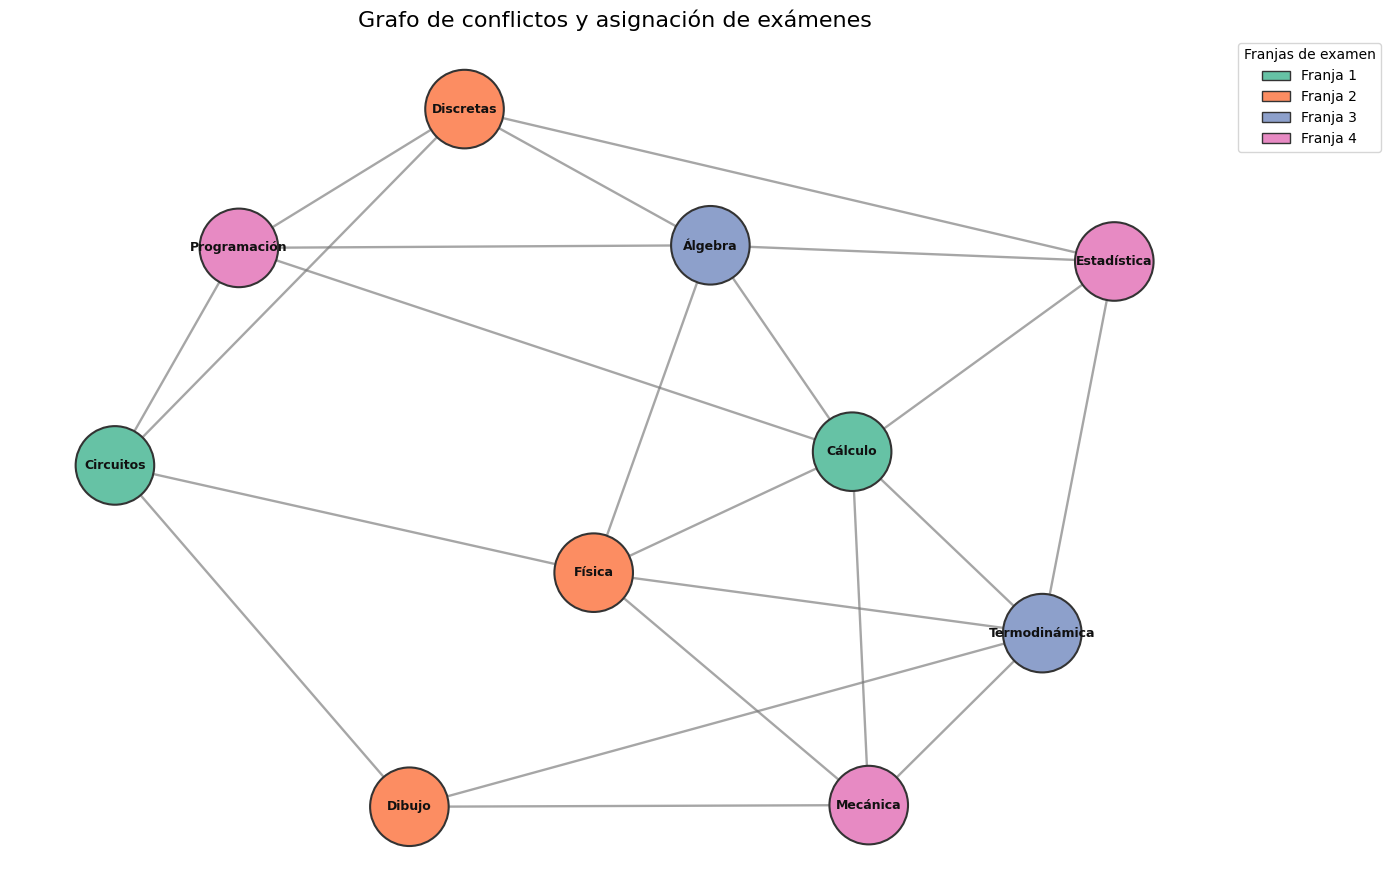

In [25]:
# ==========================================================
# VISUALIZACIÓN DEL GRAFO COLOREADO
# ==========================================================

import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


def visualizar_grafo_coloreado(grafo, colores):
    """
    Visualiza el grafo de conflictos.

    - Cada nodo representa un curso.
    - Cada arista representa un conflicto.
    - Cada color representa una franja de examen.
    """

    grafo_visual = nx.Graph()

    # Agregar los vértices.
    grafo_visual.add_nodes_from(grafo.keys())

    # Agregar las aristas.
    for curso, vecinos in grafo.items():
        for vecino in vecinos:
            grafo_visual.add_edge(curso, vecino)

    # Paleta para las franjas horarias.
    paleta = [
        "#66C2A5",  # Verde
        "#FC8D62",  # Naranja
        "#8DA0CB",  # Azul
        "#E78AC3",  # Rosado
        "#A6D854",  # Verde claro
        "#FFD92F",  # Amarillo
        "#E5C494",  # Beige
        "#B3B3B3"   # Gris
    ]

    # Asignar a cada nodo el color de su franja.
    colores_nodos = [
        paleta[(colores[curso] - 1) % len(paleta)]
        for curso in grafo_visual.nodes()
    ]

    # Posición de los nodos.
    posiciones = nx.spring_layout(
        grafo_visual,
        seed=42,
        k=1.3,
        iterations=200
    )

    plt.figure(figsize=(14, 9))

    # Dibujar las conexiones.
    nx.draw_networkx_edges(
        grafo_visual,
        posiciones,
        edge_color="#777777",
        width=1.7,
        alpha=0.65
    )

    # Dibujar los cursos.
    nx.draw_networkx_nodes(
        grafo_visual,
        posiciones,
        node_color=colores_nodos,
        node_size=3200,
        edgecolors="#333333",
        linewidths=1.5
    )

    # Dibujar los nombres.
    nx.draw_networkx_labels(
        grafo_visual,
        posiciones,
        font_size=9,
        font_weight="bold",
        font_color="#111111"
    )

    # Crear la leyenda.
    cantidad_colores = max(colores.values())

    elementos_leyenda = [
        Patch(
            facecolor=paleta[(color - 1) % len(paleta)],
            edgecolor="#333333",
            label=f"Franja {color}"
        )
        for color in range(1, cantidad_colores + 1)
    ]

    plt.legend(
        handles=elementos_leyenda,
        title="Franjas de examen",
        loc="upper left",
        bbox_to_anchor=(1.01, 1)
    )

    plt.title(
        "Grafo de conflictos y asignación de exámenes",
        fontsize=16
    )

    plt.axis("off")
    plt.tight_layout()
    plt.show()


# Visualizar el grafo creado en el ejercicio 6.
visualizar_grafo_coloreado(
    grafo_examenes,
    colores_asignados
)

# 7.) TABLAS DE VERDAD Y CIRCUITOS LÓGICOS

In [26]:
# ==========================================================
# EJERCICIO 7: TABLAS DE VERDAD Y CIRCUITOS LÓGICOS
# ==========================================================

from itertools import product
import pandas as pd
from IPython.display import display


# ----------------------------------------------------------
# OPERACIONES BOOLEANAS
# ----------------------------------------------------------

def operacion_and(valor_1, valor_2):
    """
    AND produce 1 únicamente cuando ambas entradas son 1.
    """

    return int(bool(valor_1) and bool(valor_2))


def operacion_or(valor_1, valor_2):
    """
    OR produce 1 cuando al menos una entrada es 1.
    """

    return int(bool(valor_1) or bool(valor_2))


def operacion_not(valor):
    """
    NOT invierte el valor de entrada.
    """

    return int(not bool(valor))


def operacion_xor(valor_1, valor_2):
    """
    XOR produce 1 cuando las entradas son diferentes.
    """

    return int(bool(valor_1) != bool(valor_2))


# ----------------------------------------------------------
# EXPRESIONES BOOLEANAS
# ----------------------------------------------------------

def expresion_1(A, B, C, D):
    """
    (A AND B) OR (NOT C)
    """

    parte_1 = operacion_and(A, B)
    parte_2 = operacion_not(C)

    return operacion_or(parte_1, parte_2)


def expresion_2(A, B, C, D):
    """
    (A XOR B) AND C
    """

    parte_1 = operacion_xor(A, B)

    return operacion_and(parte_1, C)


def expresion_3(A, B, C, D):
    """
    (A OR B) AND ((NOT A) OR C)
    """

    parte_1 = operacion_or(A, B)
    parte_2 = operacion_or(
        operacion_not(A),
        C
    )

    return operacion_and(parte_1, parte_2)


def expresion_4(A, B, C, D):
    """
    Expresión adicional que utiliza las cuatro variables:

    (A AND B) XOR (C OR D)
    """

    parte_1 = operacion_and(A, B)
    parte_2 = operacion_or(C, D)

    return operacion_xor(parte_1, parte_2)


# Diccionario con el nombre y la función de cada expresión.
EXPRESIONES = {
    1: {
        "nombre": "(A ∧ B) ∨ (¬C)",
        "funcion": expresion_1
    },
    2: {
        "nombre": "(A ⊕ B) ∧ C",
        "funcion": expresion_2
    },
    3: {
        "nombre": "(A ∨ B) ∧ (¬A ∨ C)",
        "funcion": expresion_3
    },
    4: {
        "nombre": "(A ∧ B) ⊕ (C ∨ D)",
        "funcion": expresion_4
    }
}


# ----------------------------------------------------------
# GENERACIÓN DE LA TABLA DE VERDAD
# ----------------------------------------------------------

def generar_tabla_verdad(funcion, nombre_resultado="Resultado"):
    """
    Genera las 16 combinaciones posibles de A, B, C y D.

    Como cada variable tiene dos valores posibles, existen:

        2^4 = 16 combinaciones
    """

    filas = []

    combinaciones = product(
        [0, 1],
        repeat=4
    )

    for A, B, C, D in combinaciones:

        resultado = funcion(A, B, C, D)

        filas.append({
            "A": A,
            "B": B,
            "C": C,
            "D": D,
            nombre_resultado: resultado
        })

    return pd.DataFrame(filas)


def mostrar_todas_las_tablas():
    """
    Genera y muestra la tabla de verdad de cada expresión.
    """

    for numero, datos in EXPRESIONES.items():

        print("\n" + "=" * 60)
        print(f"EXPRESIÓN {numero}: {datos['nombre']}")
        print("=" * 60)

        tabla = generar_tabla_verdad(
            datos["funcion"],
            nombre_resultado="Resultado"
        )

        display(tabla)


# ----------------------------------------------------------
# EVALUACIÓN DE UNA ENTRADA CONCRETA
# ----------------------------------------------------------

def validar_bit(valor, nombre):
    """
    Verifica que una entrada sea 0 o 1.
    """

    if valor not in (0, 1):
        raise ValueError(
            f"{nombre} debe ser 0 o 1."
        )


def evaluar_expresion(numero_expresion, A, B, C, D):
    """
    Evalúa una expresión con valores concretos.
    """

    if numero_expresion not in EXPRESIONES:
        raise ValueError(
            "El número de expresión no es válido."
        )

    valores = {
        "A": A,
        "B": B,
        "C": C,
        "D": D
    }

    for nombre, valor in valores.items():
        validar_bit(valor, nombre)

    funcion = EXPRESIONES[numero_expresion]["funcion"]

    return funcion(A, B, C, D)


def leer_bit(nombre):
    """
    Solicita una entrada y verifica que sea 0 o 1.
    """

    valor = int(input(f"Ingrese {nombre} (0 o 1): "))
    validar_bit(valor, nombre)

    return valor


# ----------------------------------------------------------
# MENÚ PRINCIPAL
# ----------------------------------------------------------

def programa_principal():
    while True:

        print("\n" + "=" * 60)
        print("TABLAS DE VERDAD Y CIRCUITOS LÓGICOS")
        print("=" * 60)
        print("1. Mostrar todas las tablas de verdad")
        print("2. Evaluar una expresión")
        print("3. Salir")

        opcion = input("\nSeleccione una opción: ").strip()

        if opcion == "1":
            mostrar_todas_las_tablas()

        elif opcion == "2":

            print("\nEXPRESIONES DISPONIBLES:")

            for numero, datos in EXPRESIONES.items():
                print(f"{numero}. {datos['nombre']}")

            try:
                numero_expresion = int(
                    input("\nSeleccione una expresión: ")
                )

                if numero_expresion not in EXPRESIONES:
                    raise ValueError(
                        "La expresión seleccionada no existe."
                    )

                A = leer_bit("A")
                B = leer_bit("B")
                C = leer_bit("C")
                D = leer_bit("D")

                resultado = evaluar_expresion(
                    numero_expresion,
                    A,
                    B,
                    C,
                    D
                )

                nombre = EXPRESIONES[
                    numero_expresion
                ]["nombre"]

                print("\n" + "=" * 60)
                print("RESULTADO")
                print("=" * 60)
                print(f"Expresión: {nombre}")
                print(f"A = {A}, B = {B}, C = {C}, D = {D}")
                print(f"Salida = {resultado}")

            except ValueError as error:
                print(f"\nError: {error}")

        elif opcion == "3":
            print("Programa finalizado.")
            break

        else:
            print("Opción no válida.")


programa_principal()


TABLAS DE VERDAD Y CIRCUITOS LÓGICOS
1. Mostrar todas las tablas de verdad
2. Evaluar una expresión
3. Salir

Seleccione una opción: 1

EXPRESIÓN 1: (A ∧ B) ∨ (¬C)


,A,B,C,D,Resultado
0,0,0,0,0,1
1,0,0,0,1,1
2,0,0,1,0,0
3,0,0,1,1,0
4,0,1,0,0,1
5,0,1,0,1,1
6,0,1,1,0,0
7,0,1,1,1,0
8,1,0,0,0,1
9,1,0,0,1,1



EXPRESIÓN 2: (A ⊕ B) ∧ C


,A,B,C,D,Resultado
0,0,0,0,0,0
1,0,0,0,1,0
2,0,0,1,0,0
3,0,0,1,1,0
4,0,1,0,0,0
5,0,1,0,1,0
6,0,1,1,0,1
7,0,1,1,1,1
8,1,0,0,0,0
9,1,0,0,1,0



EXPRESIÓN 3: (A ∨ B) ∧ (¬A ∨ C)


,A,B,C,D,Resultado
0,0,0,0,0,0
1,0,0,0,1,0
2,0,0,1,0,0
3,0,0,1,1,0
4,0,1,0,0,1
5,0,1,0,1,1
6,0,1,1,0,1
7,0,1,1,1,1
8,1,0,0,0,0
9,1,0,0,1,0



EXPRESIÓN 4: (A ∧ B) ⊕ (C ∨ D)


,A,B,C,D,Resultado
0,0,0,0,0,0
1,0,0,0,1,1
2,0,0,1,0,1
3,0,0,1,1,1
4,0,1,0,0,0
5,0,1,0,1,1
6,0,1,1,0,1
7,0,1,1,1,1
8,1,0,0,0,0
9,1,0,0,1,1



TABLAS DE VERDAD Y CIRCUITOS LÓGICOS
1. Mostrar todas las tablas de verdad
2. Evaluar una expresión
3. Salir

Seleccione una opción: 3
Programa finalizado.


In [40]:
# ==========================================================
# PRUEBAS DEL EJERCICIO 7: TABLAS DE VERDAD
# ==========================================================

# ----------------------------------------------------------
# PRUEBA 1
# (A ∧ B) ∨ (¬C)
# ----------------------------------------------------------

resultado_1 = evaluar_expresion(
    numero_expresion=1,
    A=1,
    B=1,
    C=0,
    D=0
)

assert resultado_1 == 1

print("PRUEBA 1 CORRECTA")
print("(1 ∧ 1) ∨ (¬0) = 1")


# ----------------------------------------------------------
# PRUEBA 2
# (A ⊕ B) ∧ C
# ----------------------------------------------------------

resultado_2 = evaluar_expresion(
    numero_expresion=2,
    A=1,
    B=0,
    C=1,
    D=0
)

assert resultado_2 == 1

print("\nPRUEBA 2 CORRECTA")
print("(1 ⊕ 0) ∧ 1 = 1")


# ----------------------------------------------------------
# PRUEBA 3
# (A ∨ B) ∧ (¬A ∨ C)
# ----------------------------------------------------------

resultado_3 = evaluar_expresion(
    numero_expresion=3,
    A=1,
    B=0,
    C=0,
    D=1
)

assert resultado_3 == 0

print("\nPRUEBA 3 CORRECTA")
print("(1 ∨ 0) ∧ (¬1 ∨ 0) = 0")


# ----------------------------------------------------------
# PRUEBA 4: EXPRESIÓN QUE UTILIZA D
# (A ∧ B) ⊕ (C ∨ D)
# ----------------------------------------------------------

resultado_4 = evaluar_expresion(
    numero_expresion=4,
    A=1,
    B=1,
    C=0,
    D=0
)

assert resultado_4 == 1

print("\nPRUEBA 4 CORRECTA")
print("(1 ∧ 1) ⊕ (0 ∨ 0) = 1")


# ----------------------------------------------------------
# PRUEBA 5: LAS TABLAS TIENEN 16 FILAS
# ----------------------------------------------------------

for numero, datos in EXPRESIONES.items():

    tabla = generar_tabla_verdad(
        datos["funcion"]
    )

    assert len(tabla) == 16
    assert set(tabla["Resultado"]) <= {0, 1}

print("\nPRUEBA 5 CORRECTA")
print(
    "Las cuatro tablas tienen las 16 combinaciones "
    "posibles de A, B, C y D."
)


# ----------------------------------------------------------
# PRUEBA 6: ENTRADA NO VÁLIDA
# ----------------------------------------------------------

try:
    evaluar_expresion(
        numero_expresion=1,
        A=2,
        B=0,
        C=1,
        D=0
    )

    raise AssertionError(
        "El programa debía rechazar A = 2."
    )

except ValueError as error:
    print("\nPRUEBA 6 CORRECTA")
    print(f"Error detectado: {error}")


print("\nTodas las pruebas del ejercicio 7 fueron correctas.")

PRUEBA 1 CORRECTA
(1 ∧ 1) ∨ (¬0) = 1

PRUEBA 2 CORRECTA
(1 ⊕ 0) ∧ 1 = 1

PRUEBA 3 CORRECTA
(1 ∨ 0) ∧ (¬1 ∨ 0) = 0

PRUEBA 4 CORRECTA
(1 ∧ 1) ⊕ (0 ∨ 0) = 1

PRUEBA 5 CORRECTA
Las cuatro tablas tienen las 16 combinaciones posibles de A, B, C y D.

PRUEBA 6 CORRECTA
Error detectado: A debe ser 0 o 1.

Todas las pruebas del ejercicio 7 fueron correctas.


# 8.) SIMPLIFICACIÓN BOOLEANA
# MÉTODO DE QUINE-MCCLUSKEY

In [27]:
# ==========================================================
# EJERCICIO 8: SIMPLIFICACIÓN BOOLEANA
# MÉTODO DE QUINE-MCCLUSKEY
# ==========================================================

from itertools import combinations
import pandas as pd
from IPython.display import display


# ----------------------------------------------------------
# VALIDACIÓN
# ----------------------------------------------------------

def validar_minterminos(minterminos, cantidad_variables):
    """
    Verifica que se utilicen 3 o 4 variables y que los
    minterminos estén dentro del rango permitido.
    """

    if cantidad_variables not in (3, 4):
        raise ValueError(
            "La cantidad de variables debe ser 3 o 4."
        )

    limite = 2 ** cantidad_variables

    for mintermino in minterminos:

        if not isinstance(mintermino, int):
            raise TypeError(
                f"El mintermino {mintermino} no es entero."
            )

        if not 0 <= mintermino < limite:
            raise ValueError(
                f"El mintermino {mintermino} está fuera del "
                f"rango 0 a {limite - 1}."
            )


# ----------------------------------------------------------
# CONVERSIÓN A BINARIO
# ----------------------------------------------------------

def convertir_a_binario(numero, cantidad_variables):
    """
    Convierte un mintermino a una cadena binaria.

    Ejemplo:
        5 con 3 variables → 101
    """

    return format(
        numero,
        f"0{cantidad_variables}b"
    )


# ----------------------------------------------------------
# COMBINACIÓN DE IMPLICANTES
# ----------------------------------------------------------

def combinar_patrones(patron_1, patron_2):
    """
    Combina dos patrones cuando difieren exactamente
    en una posición.

    Ejemplo:
        001 y 011 → 0-1

    El símbolo '-' significa que la variable se elimina.
    """

    if len(patron_1) != len(patron_2):
        return None

    diferencias = 0
    resultado = []

    for bit_1, bit_2 in zip(patron_1, patron_2):

        if bit_1 == bit_2:
            resultado.append(bit_1)

        elif bit_1 == "-" or bit_2 == "-":
            return None

        else:
            diferencias += 1
            resultado.append("-")

    if diferencias == 1:
        return "".join(resultado)

    return None


def obtener_implicantes_primos(
    minterminos,
    cantidad_variables
):
    """
    Aplica las combinaciones sucesivas de Quine-McCluskey
    hasta encontrar los implicantes primos.
    """

    implicantes_actuales = {
        convertir_a_binario(m, cantidad_variables): {m}
        for m in minterminos
    }

    implicantes_primos = {}

    while implicantes_actuales:

        patrones = list(implicantes_actuales.keys())
        patrones_combinados = set()
        siguientes_implicantes = {}

        for patron_1, patron_2 in combinations(patrones, 2):

            nuevo_patron = combinar_patrones(
                patron_1,
                patron_2
            )

            if nuevo_patron is not None:

                patrones_combinados.add(patron_1)
                patrones_combinados.add(patron_2)

                minterminos_cubiertos = (
                    implicantes_actuales[patron_1]
                    | implicantes_actuales[patron_2]
                )

                if nuevo_patron not in siguientes_implicantes:
                    siguientes_implicantes[nuevo_patron] = set()

                siguientes_implicantes[
                    nuevo_patron
                ].update(minterminos_cubiertos)

        # Los patrones que no pudieron combinarse son primos.
        for patron, cubiertos in implicantes_actuales.items():

            if patron not in patrones_combinados:

                if patron not in implicantes_primos:
                    implicantes_primos[patron] = set()

                implicantes_primos[patron].update(cubiertos)

        implicantes_actuales = siguientes_implicantes

    return implicantes_primos


# ----------------------------------------------------------
# COBERTURA DE MINTERMINOS
# ----------------------------------------------------------

def patron_cubre_mintermino(patron, mintermino):
    """
    Determina si un patrón cubre un mintermino.
    """

    binario = convertir_a_binario(
        mintermino,
        len(patron)
    )

    return all(
        bit_patron == "-"
        or bit_patron == bit_mintermino
        for bit_patron, bit_mintermino
        in zip(patron, binario)
    )


def contar_literales(patron):
    """
    Cuenta las variables que permanecen en un patrón.
    """

    return sum(
        bit != "-"
        for bit in patron
    )


def seleccionar_implicantes(
    implicantes_primos,
    minterminos
):
    """
    Selecciona una cobertura de los minterminos.

    Primero incluye los implicantes primos esenciales.
    Después prueba combinaciones para cubrir los minterminos
    restantes utilizando:

    1. La menor cantidad de implicantes.
    2. La menor cantidad total de literales.
    """

    patrones = sorted(implicantes_primos.keys())

    cobertura = {
        patron: {
            m
            for m in minterminos
            if patron_cubre_mintermino(patron, m)
        }
        for patron in patrones
    }

    esenciales = set()

    # Un implicante es esencial si es el único que cubre
    # algún mintermino.
    for mintermino in minterminos:

        patrones_que_cubren = [
            patron
            for patron in patrones
            if mintermino in cobertura[patron]
        ]

        if len(patrones_que_cubren) == 1:
            esenciales.add(patrones_que_cubren[0])

    cubiertos = set()

    for patron in esenciales:
        cubiertos.update(cobertura[patron])

    restantes = set(minterminos) - cubiertos

    if not restantes:
        return sorted(esenciales)

    candidatos = [
        patron
        for patron in patrones
        if patron not in esenciales
        and cobertura[patron] & restantes
    ]

    mejor_combinacion = None
    mejor_cantidad_literales = float("inf")

    # Se buscan primero combinaciones con menos implicantes.
    for cantidad in range(1, len(candidatos) + 1):

        for combinacion in combinations(
            candidatos,
            cantidad
        ):
            cobertura_combinacion = set()

            for patron in combinacion:
                cobertura_combinacion.update(
                    cobertura[patron]
                )

            if restantes <= cobertura_combinacion:

                cantidad_literales = sum(
                    contar_literales(patron)
                    for patron in combinacion
                )

                if cantidad_literales < mejor_cantidad_literales:
                    mejor_combinacion = combinacion
                    mejor_cantidad_literales = (
                        cantidad_literales
                    )

        # La primera cantidad que produce una cobertura
        # corresponde al menor número de implicantes.
        if mejor_combinacion is not None:
            break

    if mejor_combinacion is None:
        raise ValueError(
            "No fue posible cubrir todos los minterminos."
        )

    seleccionados = esenciales | set(mejor_combinacion)

    return sorted(seleccionados)


# ----------------------------------------------------------
# CONVERSIÓN A EXPRESIÓN BOOLEANA
# ----------------------------------------------------------

def patron_a_producto(patron, variables):
    """
    Convierte un patrón a un término producto.

    Ejemplos:
        10- → A ∧ ¬B
        --1 → C
    """

    literales = []

    for bit, variable in zip(patron, variables):

        if bit == "1":
            literales.append(variable)

        elif bit == "0":
            literales.append(f"¬{variable}")

    if not literales:
        return "1"

    return " ∧ ".join(literales)


def construir_expresion(patrones, variables):
    """
    Construye una suma de productos.
    """

    if not patrones:
        return "0"

    productos = [
        patron_a_producto(patron, variables)
        for patron in patrones
    ]

    if "1" in productos:
        return "1"

    return " ∨ ".join(
        f"({producto})"
        if "∧" in producto
        else producto
        for producto in productos
    )


# ----------------------------------------------------------
# SIMPLIFICACIÓN COMPLETA
# ----------------------------------------------------------

def simplificar_funcion(minterminos, cantidad_variables):
    """
    Simplifica una función booleana expresada mediante
    sus minterminos.
    """

    validar_minterminos(
        minterminos,
        cantidad_variables
    )

    # Se eliminan minterminos repetidos.
    minterminos = sorted(set(minterminos))

    variables = list("ABCD")[:cantidad_variables]

    if not minterminos:
        return {
            "minterminos": [],
            "implicantes_primos": {},
            "seleccionados": [],
            "expresion": "0",
            "variables": variables
        }

    implicantes_primos = obtener_implicantes_primos(
        minterminos,
        cantidad_variables
    )

    seleccionados = seleccionar_implicantes(
        implicantes_primos,
        minterminos
    )

    expresion = construir_expresion(
        seleccionados,
        variables
    )

    return {
        "minterminos": minterminos,
        "implicantes_primos": implicantes_primos,
        "seleccionados": seleccionados,
        "expresion": expresion,
        "variables": variables
    }


# ----------------------------------------------------------
# VERIFICACIÓN CON TABLA DE VERDAD
# ----------------------------------------------------------

def evaluar_patrones(patrones, mintermino):
    """
    Evalúa la expresión simplificada.
    """

    return int(
        any(
            patron_cubre_mintermino(
                patron,
                mintermino
            )
            for patron in patrones
        )
    )


def generar_tabla_verificacion(resultado):
    """
    Compara la función original y la simplificada.
    """

    variables = resultado["variables"]
    cantidad_variables = len(variables)
    minterminos = set(resultado["minterminos"])
    patrones = resultado["seleccionados"]

    filas = []

    for numero in range(2 ** cantidad_variables):

        binario = convertir_a_binario(
            numero,
            cantidad_variables
        )

        valores = {
            variable: int(bit)
            for variable, bit in zip(
                variables,
                binario
            )
        }

        original = int(numero in minterminos)
        simplificada = evaluar_patrones(
            patrones,
            numero
        )

        filas.append({
            "m": numero,
            **valores,
            "F original": original,
            "F simplificada": simplificada,
            "¿Iguales?": original == simplificada
        })

    return pd.DataFrame(filas)


# ----------------------------------------------------------
# PROGRAMA PRINCIPAL
# ----------------------------------------------------------

def programa_principal():

    print("=" * 65)
    print("SIMPLIFICACIÓN BOOLEANA")
    print("MÉTODO DE QUINE-MCCLUSKEY")
    print("=" * 65)

    try:
        cantidad_variables = int(
            input("Cantidad de variables (3 o 4): ")
        )

        entrada = input(
            "Ingrese los minterminos separados por comas: "
        ).strip()

        if entrada:
            minterminos = [
                int(valor.strip())
                for valor in entrada.split(",")
            ]
        else:
            minterminos = []

        resultado = simplificar_funcion(
            minterminos,
            cantidad_variables
        )

        print("\n" + "=" * 65)
        print("RESULTADOS")
        print("=" * 65)

        print(
            "Función original: "
            f"F = Σm{tuple(resultado['minterminos'])}"
        )

        print("\nImplicantes primos encontrados:")

        if resultado["implicantes_primos"]:

            for patron in sorted(
                resultado["implicantes_primos"]
            ):
                producto = patron_a_producto(
                    patron,
                    resultado["variables"]
                )

                cubiertos = [
                    m
                    for m in resultado["minterminos"]
                    if patron_cubre_mintermino(
                        patron,
                        m
                    )
                ]

                print(
                    f"{patron} → {producto:15} "
                    f"cubre {cubiertos}"
                )

        else:
            print("No hay implicantes primos.")

        print("\nImplicantes seleccionados:")

        if resultado["seleccionados"]:
            for patron in resultado["seleccionados"]:
                producto = patron_a_producto(
                    patron,
                    resultado["variables"]
                )

                print(f"{patron} → {producto}")

        else:
            print("Ninguno.")

        print(
            f"\nExpresión simplificada:\n"
            f"F = {resultado['expresion']}"
        )

        tabla = generar_tabla_verificacion(
            resultado
        )

        print("\nTabla de verificación:")
        display(tabla)

        if tabla["¿Iguales?"].all():
            print(
                "\nVerificación exitosa: las dos expresiones "
                "tienen la misma tabla de verdad."
            )

        else:
            print(
                "\nError: las expresiones no son equivalentes."
            )

    except (ValueError, TypeError) as error:
        print(f"\nError: {error}")


programa_principal()

SIMPLIFICACIÓN BOOLEANA
MÉTODO DE QUINE-MCCLUSKEY
Cantidad de variables (3 o 4): 3
Ingrese los minterminos separados por comas: 1,3,5,7

RESULTADOS
Función original: F = Σm(1, 3, 5, 7)

Implicantes primos encontrados:
--1 → C               cubre [1, 3, 5, 7]

Implicantes seleccionados:
--1 → C

Expresión simplificada:
F = C

Tabla de verificación:


,m,A,B,C,F original,F simplificada,¿Iguales?
0,0,0,0,0,0,0,True
1,1,0,0,1,1,1,True
2,2,0,1,0,0,0,True
3,3,0,1,1,1,1,True
4,4,1,0,0,0,0,True
5,5,1,0,1,1,1,True
6,6,1,1,0,0,0,True
7,7,1,1,1,1,1,True



Verificación exitosa: las dos expresiones tienen la misma tabla de verdad.


In [28]:
# ==========================================================
# PRUEBAS DEL EJERCICIO 8
# ==========================================================

# ----------------------------------------------------------
# PRUEBA 1: CASO SUGERIDO
# ----------------------------------------------------------

resultado_1 = simplificar_funcion(
    [1, 3, 5, 7],
    3
)

tabla_1 = generar_tabla_verificacion(resultado_1)

assert resultado_1["expresion"] == "C"
assert resultado_1["seleccionados"] == ["--1"]
assert tabla_1["¿Iguales?"].all()

print("PRUEBA 1")
print("Σm(1,3,5,7) = C")


# ----------------------------------------------------------
# PRUEBA 2: DOS GRUPOS
# ----------------------------------------------------------

resultado_2 = simplificar_funcion(
    [0, 2, 5, 7],
    3
)

tabla_2 = generar_tabla_verificacion(resultado_2)

assert tabla_2["¿Iguales?"].all()
assert len(resultado_2["seleccionados"]) == 2

print("\nPRUEBA 2")
print(f"Resultado: F = {resultado_2['expresion']}")


# ----------------------------------------------------------
# PRUEBA 3: FUNCIÓN CONSTANTE 1
# ----------------------------------------------------------

resultado_3 = simplificar_funcion(
    list(range(8)),
    3
)

tabla_3 = generar_tabla_verificacion(resultado_3)

assert resultado_3["expresion"] == "1"
assert resultado_3["seleccionados"] == ["---"]
assert tabla_3["¿Iguales?"].all()

print("\nPRUEBA 3")
print("Σm(0,1,2,3,4,5,6,7) = 1")


# ----------------------------------------------------------
# PRUEBA 4: FUNCIÓN CONSTANTE 0
# ----------------------------------------------------------

resultado_4 = simplificar_funcion(
    [],
    3
)

tabla_4 = generar_tabla_verificacion(resultado_4)

assert resultado_4["expresion"] == "0"
assert tabla_4["¿Iguales?"].all()

print("\nPRUEBA 4")
print("Una función sin minterminos es igual a 0.")


# ----------------------------------------------------------
# PRUEBA 5: FUNCIÓN DE CUATRO VARIABLES
# ----------------------------------------------------------

resultado_5 = simplificar_funcion(
    [0, 2, 5, 7, 8, 10, 13, 15],
    4
)

tabla_5 = generar_tabla_verificacion(resultado_5)

assert tabla_5["¿Iguales?"].all()
assert len(resultado_5["seleccionados"]) == 2

print("\nPRUEBA 5")
print(f"Resultado: F = {resultado_5['expresion']}")


# ----------------------------------------------------------
# PRUEBA 6: MINTERMINO FUERA DEL RANGO
# ----------------------------------------------------------

try:
    simplificar_funcion(
        [1, 3, 8],
        3
    )

    raise AssertionError(
        "El programa debía rechazar el mintermino 8."
    )

except ValueError as error:
    print("\nPRUEBA 6")
    print(f"Error detectado correctamente: {error}")



PRUEBA 1
Σm(1,3,5,7) = C

PRUEBA 2
Resultado: F = (¬A ∧ ¬C) ∨ (A ∧ C)

PRUEBA 3
Σm(0,1,2,3,4,5,6,7) = 1

PRUEBA 4
Una función sin minterminos es igual a 0.

PRUEBA 5
Resultado: F = (¬B ∧ ¬D) ∨ (B ∧ D)

PRUEBA 6
Error detectado correctamente: El mintermino 8 está fuera del rango 0 a 7.


# 9.) ENTROPÍA DE SHANNON

ENTROPÍA DE SHANNON
Ingrese dos textos para comparar su entropía.
Los espacios, números y signos también cuentan como símbolos.

Ingrese el primer texto: SebsSebasSEVASSebsSebasSEVASSebsSebasSEVASSebsSebasSEVASSebsSebasSEVASSebsSebasSEVASSebsSebasSEVASSebsSebasSEVASSebsSebasSEVASSebsSebasSEVASSebsSebasSEVASSebsSebasSEVASSebsSebasSEVASSebsSebasSEVASSebsSebasSEVASSebsSebasSEVASSebsSebasSEVASSebsSebasSEVASSebsSebasSEVAS
Ingrese el segundo texto: efyrcvwlebueuhdewh1693t7634bwvdhqfdv1t3gr8yfbHZBZGUVGZyrTFTcYFCt6rXtribhNniuoIu(/%%$rCVJnoo(/65$3STbibJOnBhuVyfcYVib jn56489414

TEXTO 1
Texto: 'SebsSebasSEVASSebsSebasSEVASSebsSebasSEVASSebsSebasSEVASSebsSebasSEVASSebsSebasSEVASSebsSebasSEVASSebsSebasSEVASSebsSebasSEVASSebsSebasSEVASSebsSebasSEVASSebsSebasSEVASSebsSebasSEVASSebsSebasSEVASSebsSebasSEVASSebsSebasSEVASSebsSebasSEVASSebsSebasSEVASSebsSebasSEVAS'
Longitud: 266 símbolos
Símbolos diferentes: 8

Frecuencias y probabilidades:


,Símbolo,Frecuencia,Probabilidad,-p·log₂(p)
0,S,76,0.285714,0.516387
1,b,38,0.142857,0.401051
2,e,38,0.142857,0.401051
3,s,38,0.142857,0.401051
4,A,19,0.071429,0.271954
5,E,19,0.071429,0.271954
6,V,19,0.071429,0.271954
7,a,19,0.071429,0.271954


Entropía de Shannon: 2.807355 bits por símbolo

TEXTO 2
Texto: 'efyrcvwlebueuhdewh1693t7634bwvdhqfdv1t3gr8yfbHZBZGUVGZyrTFTcYFCt6rXtribhNniuoIu(/%%$rCVJnoo(/65$3STbibJOnBhuVyfcYVib jn56489414'
Longitud: 127 símbolos
Símbolos diferentes: 48

Frecuencias y probabilidades:


,Símbolo,Frecuencia,Probabilidad,-p·log₂(p)
0,b,7,0.055118,0.230467
1,r,6,0.047244,0.208050
2,6,5,0.039370,0.183731
3,h,5,0.039370,0.183731
4,u,5,0.039370,0.183731
5,3,4,0.031496,0.157124
6,4,4,0.031496,0.157124
7,V,4,0.031496,0.157124
8,e,4,0.031496,0.157124
9,f,4,0.031496,0.157124


Entropía de Shannon: 5.366407 bits por símbolo

COMPARACIÓN
Entropía del texto 1: 2.807355
Entropía del texto 2: 5.366407

El texto 2 tiene mayor entropía.
Es menos predecible porque sus símbolos presentan una distribución más variada.

GRÁFICOS


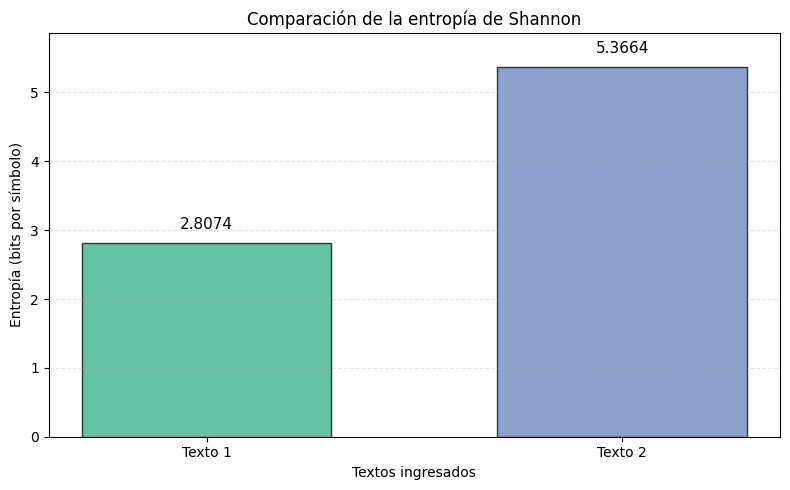

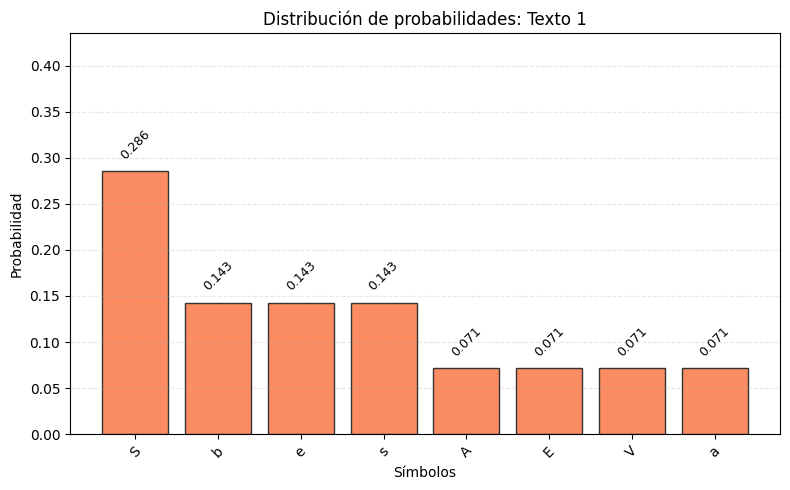

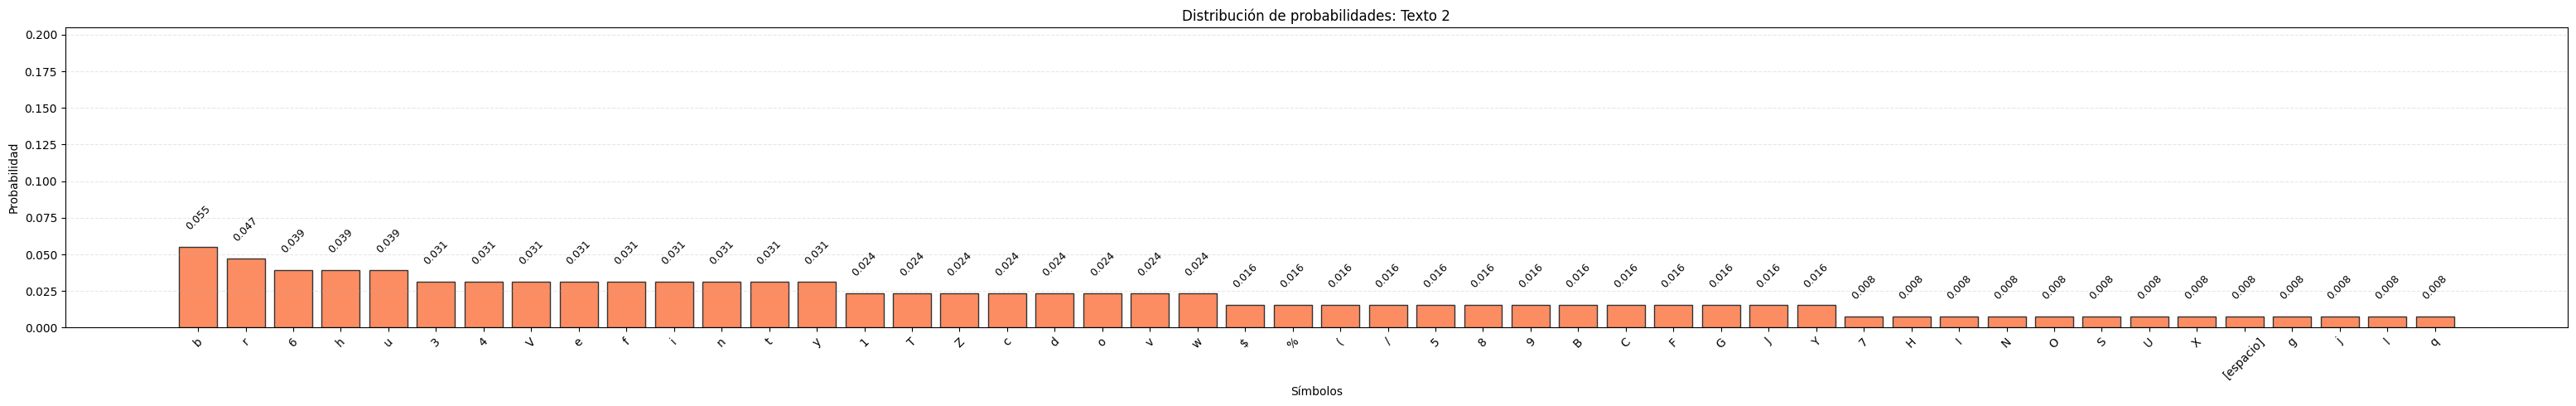

In [29]:
# ==========================================================
# EJERCICIO 9: ENTROPÍA DE SHANNON
# ==========================================================

from collections import Counter
from math import log2
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


# ----------------------------------------------------------
# REPRESENTACIÓN DE SÍMBOLOS
# ----------------------------------------------------------

def representar_simbolo(simbolo):
    """
    Produce un nombre visible para los caracteres especiales.
    """

    nombres_especiales = {
        " ": "[espacio]",
        "\n": "[salto de línea]",
        "\t": "[tabulación]"
    }

    return nombres_especiales.get(simbolo, simbolo)


# ----------------------------------------------------------
# ANÁLISIS DEL TEXTO
# ----------------------------------------------------------

def analizar_texto(texto):
    """
    Calcula la frecuencia, probabilidad y aporte a la entropía
    de cada símbolo de un texto.
    """

    if not isinstance(texto, str):
        raise TypeError(
            "El mensaje debe ser una cadena de texto."
        )

    if len(texto) == 0:
        raise ValueError(
            "El mensaje no puede estar vacío."
        )

    frecuencias = Counter(texto)
    cantidad_total = len(texto)

    filas = []
    entropia = 0

    simbolos_ordenados = sorted(
        frecuencias,
        key=lambda simbolo: (
            -frecuencias[simbolo],
            representar_simbolo(simbolo)
        )
    )

    for simbolo in simbolos_ordenados:

        frecuencia = frecuencias[simbolo]
        probabilidad = frecuencia / cantidad_total

        aporte_entropia = (
            -probabilidad * log2(probabilidad)
        )

        entropia += aporte_entropia

        filas.append({
            "Símbolo": representar_simbolo(simbolo),
            "Frecuencia": frecuencia,
            "Probabilidad": probabilidad,
            "-p·log₂(p)": aporte_entropia
        })

    tabla = pd.DataFrame(filas)

    return {
        "texto": texto,
        "longitud": cantidad_total,
        "simbolos_diferentes": len(frecuencias),
        "frecuencias": frecuencias,
        "tabla": tabla,
        "entropia": entropia
    }


# ----------------------------------------------------------
# PRESENTACIÓN DE LOS RESULTADOS
# ----------------------------------------------------------

def mostrar_analisis(resultado, nombre):
    """
    Muestra el análisis de frecuencias y entropía.
    """

    print("\n" + "=" * 65)
    print(nombre.upper())
    print("=" * 65)

    print(f"Texto: {repr(resultado['texto'])}")
    print(f"Longitud: {resultado['longitud']} símbolos")

    print(
        f"Símbolos diferentes: "
        f"{resultado['simbolos_diferentes']}"
    )

    tabla_mostrada = resultado["tabla"].copy()

    tabla_mostrada["Probabilidad"] = (
        tabla_mostrada["Probabilidad"].map(
            lambda valor: f"{valor:.6f}"
        )
    )

    tabla_mostrada["-p·log₂(p)"] = (
        tabla_mostrada["-p·log₂(p)"].map(
            lambda valor: f"{valor:.6f}"
        )
    )

    print("\nFrecuencias y probabilidades:")
    display(tabla_mostrada)

    print(
        f"Entropía de Shannon: "
        f"{resultado['entropia']:.6f} bits por símbolo"
    )


# ----------------------------------------------------------
# COMPARACIÓN DE LOS TEXTOS
# ----------------------------------------------------------

def comparar_textos(texto_1, texto_2):
    """
    Compara las entropías de dos textos.
    """

    resultado_1 = analizar_texto(texto_1)
    resultado_2 = analizar_texto(texto_2)

    mostrar_analisis(
        resultado_1,
        "Texto 1"
    )

    mostrar_analisis(
        resultado_2,
        "Texto 2"
    )

    entropia_1 = resultado_1["entropia"]
    entropia_2 = resultado_2["entropia"]

    print("\n" + "=" * 65)
    print("COMPARACIÓN")
    print("=" * 65)

    print(f"Entropía del texto 1: {entropia_1:.6f}")
    print(f"Entropía del texto 2: {entropia_2:.6f}")

    tolerancia = 1e-12

    if entropia_1 > entropia_2 + tolerancia:

        ganador = 1

        print("\nEl texto 1 tiene mayor entropía.")
        print(
            "Es menos predecible porque sus símbolos presentan "
            "una distribución más variada."
        )

    elif entropia_2 > entropia_1 + tolerancia:

        ganador = 2

        print("\nEl texto 2 tiene mayor entropía.")
        print(
            "Es menos predecible porque sus símbolos presentan "
            "una distribución más variada."
        )

    else:

        ganador = 0

        print(
            "\nLos dos textos tienen aproximadamente "
            "la misma entropía."
        )

    return resultado_1, resultado_2, ganador


# ----------------------------------------------------------
# GRÁFICO DE LAS ENTROPÍAS
# ----------------------------------------------------------

def graficar_comparacion(resultado_1, resultado_2):
    """
    Grafica las entropías de los textos ingresados
    por el usuario.
    """

    nombres = [
        "Texto 1",
        "Texto 2"
    ]

    entropias = [
        resultado_1["entropia"],
        resultado_2["entropia"]
    ]

    colores = [
        "#66C2A5",
        "#8DA0CB"
    ]

    plt.figure(figsize=(8, 5))

    barras = plt.bar(
        nombres,
        entropias,
        color=colores,
        edgecolor="#333333",
        width=0.6
    )

    desplazamiento = max(entropias) * 0.03

    if desplazamiento == 0:
        desplazamiento = 0.03

    for barra, valor in zip(barras, entropias):

        plt.text(
            barra.get_x() + barra.get_width() / 2,
            barra.get_height() + desplazamiento,
            f"{valor:.4f}",
            ha="center",
            va="bottom",
            fontsize=11
        )

    plt.ylabel("Entropía (bits por símbolo)")
    plt.xlabel("Textos ingresados")
    plt.title(
        "Comparación de la entropía de Shannon"
    )

    limite_superior = max(entropias) + 0.5

    if limite_superior <= 0.5:
        limite_superior = 0.5

    plt.ylim(0, limite_superior)

    plt.grid(
        axis="y",
        linestyle="--",
        alpha=0.3
    )

    plt.tight_layout()
    plt.show()


# ----------------------------------------------------------
# GRÁFICO DE PROBABILIDADES
# ----------------------------------------------------------

def graficar_probabilidades(resultado, nombre):
    """
    Grafica la distribución de probabilidades de los símbolos
    encontrados en uno de los textos.
    """

    tabla = resultado["tabla"]

    simbolos = tabla["Símbolo"]
    probabilidades = tabla["Probabilidad"]

    ancho = max(8, len(simbolos) * 0.65)

    plt.figure(figsize=(ancho, 5))

    barras = plt.bar(
        simbolos,
        probabilidades,
        color="#FC8D62",
        edgecolor="#333333"
    )

    for barra, valor in zip(barras, probabilidades):

        plt.text(
            barra.get_x() + barra.get_width() / 2,
            barra.get_height() + 0.01,
            f"{valor:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
            rotation=45
        )

    plt.ylabel("Probabilidad")
    plt.xlabel("Símbolos")
    plt.title(
        f"Distribución de probabilidades: {nombre}"
    )

    plt.ylim(
        0,
        min(1.15, max(probabilidades) + 0.15)
    )

    plt.xticks(rotation=45)
    plt.grid(
        axis="y",
        linestyle="--",
        alpha=0.3
    )

    plt.tight_layout()
    plt.show()


# ----------------------------------------------------------
# PROGRAMA PRINCIPAL
# ----------------------------------------------------------

def programa_principal():

    print("=" * 65)
    print("ENTROPÍA DE SHANNON")
    print("=" * 65)

    print(
        "Ingrese dos textos para comparar su entropía.\n"
        "Los espacios, números y signos también cuentan "
        "como símbolos.\n"
    )

    try:
        texto_1 = input("Ingrese el primer texto: ")
        texto_2 = input("Ingrese el segundo texto: ")

        resultado_1, resultado_2, ganador = comparar_textos(
            texto_1,
            texto_2
        )

        print("\n" + "=" * 65)
        print("GRÁFICOS")
        print("=" * 65)

        # Los gráficos utilizan directamente los resultados
        # de los textos ingresados por el usuario.
        graficar_comparacion(
            resultado_1,
            resultado_2
        )

        graficar_probabilidades(
            resultado_1,
            "Texto 1"
        )

        graficar_probabilidades(
            resultado_2,
            "Texto 2"
        )

        return resultado_1, resultado_2, ganador

    except (ValueError, TypeError) as error:
        print(f"\nError: {error}")
        return None, None, None


# Ejecutar el programa.
resultado_texto_1, resultado_texto_2, ganador = (
    programa_principal()
)

In [41]:
# ==========================================================
# PRUEBAS DEL EJERCICIO 9: ENTROPÍA DE SHANNON
# ==========================================================

# ----------------------------------------------------------
# PRUEBA 1: MENSAJE COMPLETAMENTE REPETITIVO
# ----------------------------------------------------------

resultado_1 = analizar_texto(
    "AAAAAAAAAA"
)

assert resultado_1["frecuencias"]["A"] == 10
assert resultado_1["entropia"] == 0

print("PRUEBA 1 CORRECTA")
print("H(AAAAAAAAAA) = 0 bits por símbolo")


# ----------------------------------------------------------
# PRUEBA 2: DOS SÍMBOLOS EQUIPROBABLES
# ----------------------------------------------------------

resultado_2 = analizar_texto(
    "AABB"
)

assert resultado_2["frecuencias"]["A"] == 2
assert resultado_2["frecuencias"]["B"] == 2
assert abs(
    resultado_2["entropia"] - 1
) < 1e-12

print("\nPRUEBA 2 CORRECTA")
print("H(AABB) = 1 bit por símbolo")


# ----------------------------------------------------------
# PRUEBA 3: CUATRO SÍMBOLOS EQUIPROBABLES
# ----------------------------------------------------------

resultado_3 = analizar_texto(
    "ABCD"
)

assert abs(
    resultado_3["entropia"] - 2
) < 1e-12

print("\nPRUEBA 3 CORRECTA")
print("H(ABCD) = 2 bits por símbolo")


# ----------------------------------------------------------
# PRUEBA 4: COMPARACIÓN DE ENTROPÍAS
# ----------------------------------------------------------

repetitivo = analizar_texto(
    "AAAAAAAA"
)

variado = analizar_texto(
    "ABCDEFGH"
)

assert repetitivo["entropia"] == 0

assert abs(
    variado["entropia"] - 3
) < 1e-12

assert (
    variado["entropia"]
    > repetitivo["entropia"]
)

print("\nPRUEBA 4 CORRECTA")
print(
    "El texto variado tiene mayor entropía "
    "que el texto repetitivo."
)


# ----------------------------------------------------------
# PRUEBA 5: LOS ESPACIOS TAMBIÉN SON SÍMBOLOS
# ----------------------------------------------------------

resultado_5 = analizar_texto(
    "A A"
)

assert resultado_5["frecuencias"]["A"] == 2
assert resultado_5["frecuencias"][" "] == 1
assert resultado_5["simbolos_diferentes"] == 2

print("\nPRUEBA 5 CORRECTA")
print("El espacio fue contado como un símbolo.")


# ----------------------------------------------------------
# PRUEBA 6: TEXTO VACÍO
# ----------------------------------------------------------

try:
    analizar_texto("")

    raise AssertionError(
        "El programa debía rechazar el texto vacío."
    )

except ValueError as error:
    print("\nPRUEBA 6 CORRECTA")
    print(f"Error detectado: {error}")


print("\nTodas las pruebas del ejercicio 9 fueron correctas.")

PRUEBA 1 CORRECTA
H(AAAAAAAAAA) = 0 bits por símbolo

PRUEBA 2 CORRECTA
H(AABB) = 1 bit por símbolo

PRUEBA 3 CORRECTA
H(ABCD) = 2 bits por símbolo

PRUEBA 4 CORRECTA
El texto variado tiene mayor entropía que el texto repetitivo.

PRUEBA 5 CORRECTA
El espacio fue contado como un símbolo.

PRUEBA 6 CORRECTA
Error detectado: El mensaje no puede estar vacío.

Todas las pruebas del ejercicio 9 fueron correctas.


#

# 10.) QUBIT

SIMULADOR BÁSICO DE UN QUBIT
Estados iniciales disponibles:
0. Estado |0⟩
1. Estado |1⟩

Compuertas disponibles:
X: intercambia |0⟩ y |1⟩
Z: cambia la fase de |1⟩
H: crea o elimina superposición

Seleccione el estado inicial (0 o 1): 1
Ingrese la secuencia de compuertas (ejemplo H,X,Z): H,X,Z

EVOLUCIÓN DEL QUBIT

Después de: Inicial:
[0.+0.j 1.+0.j]
|ψ⟩ = (0.0000)|0⟩ + (1.0000)|1⟩

Después de: H:
[ 0.70710678+0.j -0.70710678+0.j]
|ψ⟩ = (0.7071)|0⟩ + (-0.7071)|1⟩

Después de: X:
[-0.70710678+0.j  0.70710678+0.j]
|ψ⟩ = (-0.7071)|0⟩ + (0.7071)|1⟩

Después de: Z:
[-0.70710678+0.j -0.70710678+0.j]
|ψ⟩ = (-0.7071)|0⟩ + (-0.7071)|1⟩

RESULTADOS
Secuencia aplicada: H → X → Z

Estado final:
[-0.70710678+0.j -0.70710678+0.j]
|ψ⟩ = (-0.7071)|0⟩ + (-0.7071)|1⟩

Probabilidades teóricas:
P(0) = 0.500000 = 50.00%
P(1) = 0.500000 = 50.00%

Resultado de 1000 mediciones:
Se obtuvo 0: 495 veces (49.50%)
Se obtuvo 1: 505 veces (50.50%)


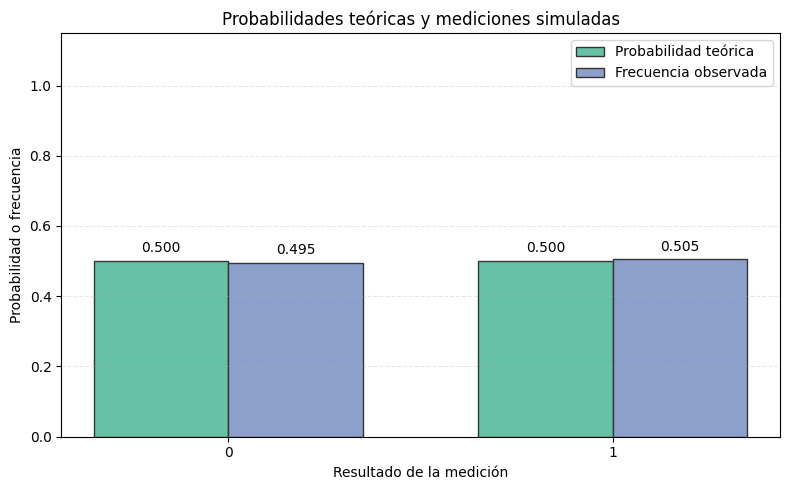

In [31]:
# ==========================================================
# EJERCICIO 10: SIMULADOR BÁSICO DE UN QUBIT
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt


# ----------------------------------------------------------
# ESTADOS BÁSICOS
# ----------------------------------------------------------

KET_0 = np.array(
    [1, 0],
    dtype=complex
)

KET_1 = np.array(
    [0, 1],
    dtype=complex
)


# ----------------------------------------------------------
# COMPUERTAS CUÁNTICAS
# ----------------------------------------------------------

COMPUERTA_X = np.array(
    [
        [0, 1],
        [1, 0]
    ],
    dtype=complex
)

COMPUERTA_Z = np.array(
    [
        [1, 0],
        [0, -1]
    ],
    dtype=complex
)

COMPUERTA_H = (
    1 / np.sqrt(2)
) * np.array(
    [
        [1, 1],
        [1, -1]
    ],
    dtype=complex
)

COMPUERTAS = {
    "X": COMPUERTA_X,
    "Z": COMPUERTA_Z,
    "H": COMPUERTA_H
}


# ----------------------------------------------------------
# VALIDACIÓN DEL ESTADO
# ----------------------------------------------------------

def validar_estado(estado):
    """
    Verifica que el estado tenga dos amplitudes y esté
    normalizado.
    """

    estado = np.asarray(
        estado,
        dtype=complex
    )

    if estado.shape != (2,):
        raise ValueError(
            "El estado debe ser un vector de dos entradas."
        )

    norma = np.sum(
        np.abs(estado) ** 2
    )

    if not np.isclose(norma, 1, atol=1e-10):
        raise ValueError(
            "El estado no está normalizado: "
            "|α|² + |β|² debe ser igual a 1."
        )

    return estado


# ----------------------------------------------------------
# APLICACIÓN DE COMPUERTAS
# ----------------------------------------------------------

def aplicar_compuerta(estado, nombre_compuerta):
    """
    Aplica una compuerta X, Z o H al estado del qubit.
    """

    estado = validar_estado(estado)
    nombre_compuerta = nombre_compuerta.upper()

    if nombre_compuerta not in COMPUERTAS:
        raise ValueError(
            f"La compuerta '{nombre_compuerta}' no existe. "
            "Las opciones válidas son X, Z y H."
        )

    matriz = COMPUERTAS[nombre_compuerta]

    nuevo_estado = matriz @ estado

    return nuevo_estado


def aplicar_secuencia(estado_inicial, secuencia):
    """
    Aplica una secuencia de compuertas en el mismo orden
    en que fue ingresada.

    Ejemplo:
        ["H", "X", "Z"]
    """

    estado = validar_estado(estado_inicial).copy()
    historial = [("Inicial", estado.copy())]

    for compuerta in secuencia:

        estado = aplicar_compuerta(
            estado,
            compuerta
        )

        historial.append(
            (compuerta.upper(), estado.copy())
        )

    return estado, historial


# ----------------------------------------------------------
# PROBABILIDADES DE MEDICIÓN
# ----------------------------------------------------------

def calcular_probabilidades(estado):
    """
    Calcula:

        P(0) = |α|²
        P(1) = |β|²
    """

    estado = validar_estado(estado)

    probabilidades = np.abs(estado) ** 2

    # Corrección de posibles errores numéricos pequeños.
    probabilidades = probabilidades / np.sum(
        probabilidades
    )

    return probabilidades


# ----------------------------------------------------------
# SIMULACIÓN DE MEDICIONES
# ----------------------------------------------------------

def simular_mediciones(
    estado,
    cantidad_mediciones=1000,
    semilla=None
):
    """
    Simula mediciones del qubit utilizando sus probabilidades.
    """

    if cantidad_mediciones <= 0:
        raise ValueError(
            "La cantidad de mediciones debe ser positiva."
        )

    probabilidades = calcular_probabilidades(estado)

    generador = np.random.default_rng(semilla)

    mediciones = generador.choice(
        [0, 1],
        size=cantidad_mediciones,
        p=probabilidades
    )

    conteos = np.bincount(
        mediciones,
        minlength=2
    )

    frecuencias = conteos / cantidad_mediciones

    return {
        "cantidad": cantidad_mediciones,
        "conteos": conteos,
        "frecuencias": frecuencias,
        "mediciones": mediciones
    }


# ----------------------------------------------------------
# PRESENTACIÓN DEL ESTADO
# ----------------------------------------------------------

def formatear_amplitud(amplitud):
    """
    Convierte una amplitud compleja a un texto legible.
    """

    parte_real = amplitud.real
    parte_imaginaria = amplitud.imag

    if abs(parte_real) < 1e-10:
        parte_real = 0

    if abs(parte_imaginaria) < 1e-10:
        parte_imaginaria = 0

    if parte_imaginaria == 0:
        return f"{parte_real:.4f}"

    if parte_real == 0:
        return f"{parte_imaginaria:.4f}j"

    return (
        f"{parte_real:.4f}"
        f"{parte_imaginaria:+.4f}j"
    )


def mostrar_estado(estado, nombre="Estado"):
    """
    Muestra el vector y la notación del estado cuántico.
    """

    alpha = estado[0]
    beta = estado[1]

    print(f"\n{nombre}:")
    print(estado)

    print(
        f"|ψ⟩ = ({formatear_amplitud(alpha)})|0⟩ "
        f"+ ({formatear_amplitud(beta)})|1⟩"
    )


def mostrar_historial(historial):
    """
    Muestra el estado después de cada compuerta.
    """

    print("\n" + "=" * 65)
    print("EVOLUCIÓN DEL QUBIT")
    print("=" * 65)

    for paso, estado in historial:
        mostrar_estado(
            estado,
            f"Después de: {paso}"
        )


# ----------------------------------------------------------
# GRÁFICO DE RESULTADOS
# ----------------------------------------------------------

def graficar_resultados(
    probabilidades,
    frecuencias
):
    """
    Compara las probabilidades teóricas con las frecuencias
    obtenidas en las mediciones simuladas.
    """

    resultados = ["0", "1"]
    posiciones = np.arange(2)
    ancho = 0.35

    plt.figure(figsize=(8, 5))

    barras_teoricas = plt.bar(
        posiciones - ancho / 2,
        probabilidades,
        width=ancho,
        color="#66C2A5",
        edgecolor="#333333",
        label="Probabilidad teórica"
    )

    barras_simuladas = plt.bar(
        posiciones + ancho / 2,
        frecuencias,
        width=ancho,
        color="#8DA0CB",
        edgecolor="#333333",
        label="Frecuencia observada"
    )

    for barras in (
        barras_teoricas,
        barras_simuladas
    ):
        for barra in barras:

            valor = barra.get_height()

            plt.text(
                barra.get_x() + barra.get_width() / 2,
                valor + 0.025,
                f"{valor:.3f}",
                ha="center",
                fontsize=10
            )

    plt.xticks(
        posiciones,
        resultados
    )

    plt.xlabel("Resultado de la medición")
    plt.ylabel("Probabilidad o frecuencia")
    plt.title(
        "Probabilidades teóricas y mediciones simuladas"
    )

    plt.ylim(0, 1.15)
    plt.legend()
    plt.grid(
        axis="y",
        linestyle="--",
        alpha=0.3
    )

    plt.tight_layout()
    plt.show()


# ----------------------------------------------------------
# LECTURA DE LA SECUENCIA
# ----------------------------------------------------------

def leer_secuencia(texto):
    """
    Convierte el texto ingresado en una lista de compuertas.

    Formatos aceptados:
        H,X,Z
        H X Z
        HXZ
    """

    texto = texto.upper().strip()

    if texto == "":
        return []

    texto = texto.replace(",", "")
    texto = texto.replace(" ", "")

    secuencia = list(texto)

    for compuerta in secuencia:

        if compuerta not in COMPUERTAS:
            raise ValueError(
                f"La compuerta '{compuerta}' no es válida. "
                "Utilice solamente X, Z y H."
            )

    return secuencia


# ----------------------------------------------------------
# PROGRAMA PRINCIPAL
# ----------------------------------------------------------

def programa_principal():

    print("=" * 65)
    print("SIMULADOR BÁSICO DE UN QUBIT")
    print("=" * 65)

    print("Estados iniciales disponibles:")
    print("0. Estado |0⟩")
    print("1. Estado |1⟩")

    print("\nCompuertas disponibles:")
    print("X: intercambia |0⟩ y |1⟩")
    print("Z: cambia la fase de |1⟩")
    print("H: crea o elimina superposición")

    try:
        estado_inicial_elegido = int(
            input("\nSeleccione el estado inicial (0 o 1): ")
        )

        if estado_inicial_elegido == 0:
            estado_inicial = KET_0.copy()

        elif estado_inicial_elegido == 1:
            estado_inicial = KET_1.copy()

        else:
            raise ValueError(
                "El estado inicial debe ser 0 o 1."
            )

        entrada_compuertas = input(
            "Ingrese la secuencia de compuertas "
            "(ejemplo H,X,Z): "
        )

        secuencia = leer_secuencia(
            entrada_compuertas
        )

        estado_final, historial = aplicar_secuencia(
            estado_inicial,
            secuencia
        )

        probabilidades = calcular_probabilidades(
            estado_final
        )

        simulacion = simular_mediciones(
            estado_final,
            cantidad_mediciones=1000
        )

        mostrar_historial(historial)

        print("\n" + "=" * 65)
        print("RESULTADOS")
        print("=" * 65)

        if secuencia:
            print(
                f"Secuencia aplicada: "
                f"{' → '.join(secuencia)}"
            )
        else:
            print("No se aplicaron compuertas.")

        mostrar_estado(
            estado_final,
            "Estado final"
        )

        print("\nProbabilidades teóricas:")
        print(
            f"P(0) = {probabilidades[0]:.6f} "
            f"= {probabilidades[0] * 100:.2f}%"
        )
        print(
            f"P(1) = {probabilidades[1]:.6f} "
            f"= {probabilidades[1] * 100:.2f}%"
        )

        print("\nResultado de 1000 mediciones:")
        print(
            f"Se obtuvo 0: "
            f"{simulacion['conteos'][0]} veces "
            f"({simulacion['frecuencias'][0] * 100:.2f}%)"
        )
        print(
            f"Se obtuvo 1: "
            f"{simulacion['conteos'][1]} veces "
            f"({simulacion['frecuencias'][1] * 100:.2f}%)"
        )

        graficar_resultados(
            probabilidades,
            simulacion["frecuencias"]
        )

        return {
            "estado_inicial": estado_inicial,
            "secuencia": secuencia,
            "estado_final": estado_final,
            "probabilidades": probabilidades,
            "simulacion": simulacion
        }

    except (ValueError, TypeError) as error:
        print(f"\nError: {error}")
        return None


# Ejecutar el programa.
resultado_simulacion = programa_principal()

In [32]:
# ==========================================================
# PRUEBAS DEL EJERCICIO 10
# ==========================================================

# ----------------------------------------------------------
# PRUEBA 1: X|0⟩ = |1⟩
# ----------------------------------------------------------

estado_prueba_1 = aplicar_compuerta(
    KET_0,
    "X"
)

probabilidades_1 = calcular_probabilidades(
    estado_prueba_1
)

assert np.allclose(
    estado_prueba_1,
    KET_1,
    atol=1e-10
)

assert np.allclose(
    probabilidades_1,
    [0, 1],
    atol=1e-10
)

print("PRUEBA 1 CORRECTA")
print("X|0⟩ = |1⟩")
print(f"Estado: {estado_prueba_1}")
print(f"Probabilidades: {probabilidades_1}")


# ----------------------------------------------------------
# PRUEBA 2: H|0⟩ PRODUCE 50% Y 50%
# ----------------------------------------------------------

estado_prueba_2 = aplicar_compuerta(
    KET_0,
    "H"
)

probabilidades_2 = calcular_probabilidades(
    estado_prueba_2
)

mediciones_2 = simular_mediciones(
    estado_prueba_2,
    cantidad_mediciones=1000,
    semilla=42
)

assert np.allclose(
    probabilidades_2,
    [0.5, 0.5],
    atol=1e-10
)

assert abs(
    mediciones_2["frecuencias"][0] - 0.5
) < 0.06

assert abs(
    mediciones_2["frecuencias"][1] - 0.5
) < 0.06

print("\nPRUEBA 2 CORRECTA")
print("H|0⟩ produce probabilidades de 50% y 50%.")
print(f"Estado: {estado_prueba_2}")
print(f"Probabilidades: {probabilidades_2}")
print(f"Conteos observados: {mediciones_2['conteos']}")


# ----------------------------------------------------------
# PRUEBA 3: HH|0⟩ = |0⟩
# ----------------------------------------------------------

estado_prueba_3, historial_3 = aplicar_secuencia(
    KET_0,
    ["H", "H"]
)

probabilidades_3 = calcular_probabilidades(
    estado_prueba_3
)

assert np.allclose(
    estado_prueba_3,
    KET_0,
    atol=1e-10
)

assert np.allclose(
    probabilidades_3,
    [1, 0],
    atol=1e-10
)

print("\nPRUEBA 3 CORRECTA")
print("HH|0⟩ = |0⟩")
print(f"Estado: {estado_prueba_3}")
print(f"Probabilidades: {probabilidades_3}")


# ----------------------------------------------------------
# PRUEBA 4: Z|1⟩ = -|1⟩
# ----------------------------------------------------------

estado_prueba_4 = aplicar_compuerta(
    KET_1,
    "Z"
)

probabilidades_4 = calcular_probabilidades(
    estado_prueba_4
)

assert np.allclose(
    estado_prueba_4,
    -KET_1,
    atol=1e-10
)

assert np.allclose(
    probabilidades_4,
    [0, 1],
    atol=1e-10
)

print("\nPRUEBA 4 CORRECTA")
print("Z|1⟩ = -|1⟩")
print(f"Estado: {estado_prueba_4}")
print(f"Probabilidades: {probabilidades_4}")


# ----------------------------------------------------------
# PRUEBA 5: COMPUERTA NO VÁLIDA
# ----------------------------------------------------------

try:
    aplicar_compuerta(
        KET_0,
        "Y"
    )

    raise AssertionError(
        "El programa debía rechazar la compuerta Y."
    )

except ValueError as error:
    print("\nPRUEBA 5 CORRECTA")
    print(f"Error detectado: {error}")


PRUEBA 1 CORRECTA
X|0⟩ = |1⟩
Estado: [0.+0.j 1.+0.j]
Probabilidades: [0. 1.]

PRUEBA 2 CORRECTA
H|0⟩ produce probabilidades de 50% y 50%.
Estado: [0.70710678+0.j 0.70710678+0.j]
Probabilidades: [0.5 0.5]
Conteos observados: [503 497]

PRUEBA 3 CORRECTA
HH|0⟩ = |0⟩
Estado: [1.+0.j 0.+0.j]
Probabilidades: [1. 0.]

PRUEBA 4 CORRECTA
Z|1⟩ = -|1⟩
Estado: [ 0.+0.j -1.+0.j]
Probabilidades: [0. 1.]

PRUEBA 5 CORRECTA
Error detectado: La compuerta 'Y' no existe. Las opciones válidas son X, Z y H.
